# **Problem Statement**

## Business Context

In last-mile logistics, roughly 10% of all shipments encounter delivery exceptions - failed attempts, address mismatches, damaged packages, refused deliveries, and weather delays. Each failed delivery costs in direct reattempt expenses, while the downstream impact is far steeper: consumers stop shopping with a retailer after just 2-3 failed deliveries, and supply chain disruptions cost companies millions per year.

Despite these costs, most organizations still handle exception triage and resolution manually. Operations staff read through status logs and messy driver notes, cross-reference customer profiles and internal playbooks, decide on a resolution action, and draft customer notifications - all under time pressure. Teams rely on support tickets, tribal knowledge, and rigid rule engines that cannot handle the nuanced, multi-factor judgment calls that real exceptions demand. A VIP customer with a perishable package and a broken gate code on a second attempt requires a fundamentally different resolution than a standard customer's first failed attempt on a non-perishable item - but manual processes treat them with the same slow, inconsistent workflow.

Key KPIs affected include:
- Exception resolution time (constrained by manual triage throughput)
- Escalation accuracy (missed or unnecessary supervisor escalations)
- Customer communication quality and personalization
- Cost per exception (reattempt costs, spoilage write-offs, unnecessary truck rolls)
- Customer retention and lifetime value

If unaddressed, logistics providers face rising exception-handling costs, inconsistent service quality, preventable customer churn, and loss of competitive ground to players who are already investing in AI-powered exception detection and response automation.

By applying an AI-powered multi-agent system that ingests delivery logs, cross-references customer profiles and locker availability, retrieves resolution policy from an operational playbook, and generates validated decisions with personalized customer communications, logistics providers can automate the full exception-handling pipeline from detection through resolution, with built-in quality validation and supervisor escalation where policy requires it.


## Objective

The objective is to build a POC of an AI-powered multi-agent delivery exception handling system for the last-mile delivery operations of a mid-sized retailer that:
- uses the operator's available data to process exceptions end-to-end,
- ingests raw delivery status logs, including noisy, duplicated, and multi-row shipment events, and correctly identifies actionable exceptions versus routine operational noise,
- decides the appropriate resolution action (reschedule, reroute to locker, replace, or return to sender) by reasoning over playbook rules, customer context, package constraints, and locker eligibility, while respecting operational policies around perishable handling, fragile thresholds, and locker capacity.
- escalates to a human supervisor when policy requires it and avoids unnecessary escalations that waste supervisor capacity,
- generates personalized customer notifications with tone, channel, and content calibrated to customer tier and exception severity, and
- produces auditable decisions with step-by-step rationale, critical validation traces, and system evaluation metrics across five dimensions: task completion rate, escalation accuracy, tool call accuracy, reasoning trajectory coherence, and end-to-end latency.

The end goal is to demonstrate measurable accuracy and consistency on curated exception scenarios sufficient to justify scaling the approach to real-time operations with live delivery feeds, broader exception taxonomies, and multi-region deployment.


## Data Dictionary

The data comprises three types of files.

### SQLite Database (`customers.db`)

**Table: `customers`** - 12 records

| Attribute | Type | Values / Description |
|:---|:---|:---|
| customer_id | string | Primary key (`CUST-001` to `CUST-012`), Foreign key in delivery logs |
| name | string | Customer full name (**PII**) |
| tier | string | STANDARD, PREMIUM, VIP |
| preferred_channel | string | SMS, EMAIL |
| exceptions_last_90d | integer | Range: 0-6 |
| active_credit | float | Range: \$0.00-\$20.00 |

**Table: `lockers`** - 6 records

| Attribute | Type | Values / Description |
|:---|:---|:---|
| locker_id | string | Primary key (`LOC-001` to `LOC-006`) |
| address | string | Locker street address |
| zip_code | string | 10001-10006 |
| capacity_status | string | AVAILABLE, LIMITED, FULL |
| operating_hours | string | e.g., "6AM-10PM" or "24 hours" |
| max_package_size | string | SMALL, MEDIUM, LARGE |

### CSV Files

**Delivery Status Logs (`delivery_logs.csv`)** - 13 rows, 10 unique shipments

| Attribute | Type | Values / Description |
|:---|:---|:---|
| shipment_id | string | `SHP-001` to `SHP-01`0, Multiple rows may share the same ID for multi-event shipments. |
| timestamp | datetime | ISO format |
| status_code | string | One of seven codes: DELIVERED, ATTEMPTED, DAMAGED, ADDRESS_ISSUE, REFUSED, WEATHER_DELAY, SCANNED |
| status_description | string | Free-text driver/handler notes |
| customer_id | string | Foreign key to `customers` table (`CUST-001` to `CUST-012`) |
| delivery_address | string | Full address including zip code |
| package_type | string | STANDARD, PERISHABLE, FRAGILE |
| package_size | string | SMALL, MEDIUM, LARGE |
| attempt_number | integer | 0 for pre-delivery scans, 1+ for delivery attempts |
| is_duplicate_scan | boolean | True for repeated scan events |

**Ground Truth Labels (`ground_truth.csv`)** - 13 rows, aligned 1:1 with delivery logs

| Attribute | Type | Values / Description |
|:---|:---|:---|
| shipment_id | string | Matches delivery logs (`SHP-001` to `SHP-010`) |
| is_exception | string | YES, NO |
| expected_resolution | string | RESCHEDULE, REPLACE, REROUTE_TO_LOCKER, RETURN_TO_SENDER, N/A |
| expected_tone | string | FORMAL, CASUAL, N/A |
| should_escalate | string | YES, NO, N/A |
| ground_truth_reasoning | string | Step-by-step justification tracing each label to specific playbook rules, customer attributes, and locker constraints |

### Exception Resolution Playbook (`exception_resolution_playbook.pdf`)

An internal operations manual for human dispatchers in natural language.

# **Please read the instructions carefully before starting the project.**

This is a Python Notebook file with blocks of code pre-filled in alignment with a possible solution for the business use case at hand, and some blank sections where the code has to be written from scratch.

* Please feel free to
    * leverage the pre-filled code blocks as they are, or
    * update the pre-filled code blocks to incorporate necessary changes as per your desired solution workflow for the business problem at hand, or
    * discard the pre-filled code blocks and write the entire code from scratch
* Notebook sections and code blocks that contain instructions and tasks to be performed are mentioned.
* Blanks '\_\_\_\_\_' are provided in the notebook that need to be filled with an appropriate code to get the correct result.
    * With every '\_\_\_\_\_' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please sequentially run the code cells from the beginning to avoid any unnecessary errors.
* Add the results/observations derived from the analysis under the respective notebook sections as per the grading rubric requirements.

# **Installing and Importing Necessary Libraries and Dependencies**

In [ ]:
import warnings
warnings.filterwarnings('ignore')

!pip install -q -U \
    langchain \
    langchain-openai \
    langchain-community \
    langchain-core \
    langchain-chroma \
    langchain-huggingface \
    langchain-text-splitters \
    langgraph \
    langsmith \
    sentence-transformers \
    pypdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 813.1/813.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for VSCode/Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [ ]:
# write the code to import all necessary libraries
# Standard library - file handling, timing, database, data structures
import os
import json
import csv
import time
import sqlite3
import pandas as pd
from typing import Literal, Optional, Annotated, TypedDict
from datetime import datetime
from collections import defaultdict, Counter

# Pydantic - structured output schemas and validation
from pydantic import BaseModel, Field, model_validator

# LangChain - LLM interface, message types, document objects, tool decorator
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.documents import Document
from langchain_core.tools import tool

# Document processing - PDF text extraction, chunking, embeddings, vector store
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from pypdf import PdfReader

# Agent orchestration - state graph, traceability
from langgraph.graph import StateGraph, END
from langsmith import traceable

# Notebook display - for rendering workflow graph
from IPython.display import Image

# Suppress non-critical warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# **LLM and Agent Observability Setup**

We load all OpenAI and LangSmith credentials from a secure `config.json` file and store them as environment variables.

In [ ]:
# Load the JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary

    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                               # Extract OpenAI API key
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")                             # Extract OpenAI base URL

    LANGCHAIN_TRACING_V2 = config.get("LANGCHAIN_TRACING_V2")                   # Extract LangSmith tracing flag
    LANGCHAIN_API_KEY = config.get("LANGCHAIN_API_KEY")                         # Extract LangSmith API key
    LANGCHAIN_PROJECT = config.get("LANGCHAIN_PROJECT")                         # Extract LangSmith project name


# Store OpenAI credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                   # Set OpenAI API key
os.environ['OPENAI_BASE_URL'] = OPENAI_API_BASE                                 # Set OpenAI API base URL


# Store LangSmith credentials in environment variables
os.environ['LANGCHAIN_TRACING_V2'] = LANGCHAIN_TRACING_V2                       # Enable LangSmith tracing
os.environ['LANGCHAIN_API_KEY'] = LANGCHAIN_API_KEY                             # Set LangSmith API key
os.environ['LANGCHAIN_PROJECT'] = LANGCHAIN_PROJECT                             # Set LangSmith project

In [ ]:
# write the code to set up the LLM(s)
# as we need grounded truth and no hallucianations, lets set temp=0
BASE_LLM = "gpt-4o-mini" # Base LLM model
EVAL_LLM = "gpt-4o" # Evaluation LLM model
llm = ChatOpenAI(model=BASE_LLM, temperature=0) # Base LLM client

eval_llm = ChatOpenAI(model=EVAL_LLM, temperature=0) # Evaluation LLM client

# **Data Loading and Vector Database Setup**

## Loading the CSV files

In [ ]:
#each files to be loaded ->  delivery_logs.csv ground_truth.csv
DELIVERY_LOGS_PATH = "/content/delivery_logs.csv"
GROUND_TRUTH_PATH = "/content/ground_truth.csv"
delivery_logs_data = pd.read_csv(DELIVERY_LOGS_PATH)
ground_truth_data = pd.read_csv(GROUND_TRUTH_PATH)

In [ ]:
#check info releated to these csv files
print(delivery_logs_data.info())
print(delivery_logs_data.head())
print(ground_truth_data.info())
print(ground_truth_data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   shipment_id         13 non-null     object
 1   timestamp           13 non-null     object
 2   status_code         13 non-null     object
 3   status_description  13 non-null     object
 4   customer_id         13 non-null     object
 5   delivery_address    13 non-null     object
 6   package_type        13 non-null     object
 7   package_size        13 non-null     object
 8   attempt_number      13 non-null     int64 
 9   is_duplicate_scan   13 non-null     bool  
dtypes: bool(1), int64(1), object(8)
memory usage: 1.1+ KB
None
  shipment_id            timestamp    status_code  \
0     SHP-001  2026-03-05T10:14:00      DELIVERED   
1     SHP-002  2026-03-05T11:05:00      ATTEMPTED   
2     SHP-002  2026-03-05T11:07:00      ATTEMPTED   
3     SHP-003  2026-03-05T09:45:00  ADDRESS_I

### Observations:
Delivery logs and ground truth data loaded. `delivery_logs` contains 13 entries, 10 columns. `ground_truth_data` contains 13 entries, 6 columns. Data types appear appropriate.

## Loading the SQLite database

In [ ]:
#files to be loaded -> customers.db data base file
CUSTOMERS_DB_PATH = "/content/customers.db"
cust_db_conn = sqlite3.connect(CUSTOMERS_DB_PATH)
cust_db_conn.row_factory = sqlite3.Row
#cursor
db_cursor = cust_db_conn.cursor()

In [ ]:
#verify the DB connection with some queries
db_cursor = cust_db_conn.cursor()
db_cursor.execute("SELECT * FROM customers LIMIT 5")
rows = db_cursor.fetchall()
for row in rows:
    print(dict(row))
# get some lockers a well
db_cursor.execute("SELECT * FROM lockers LIMIT 5")
rows = db_cursor.fetchall()
for row in rows:
    print(dict(row))
#removed close connection to enable further execution

{'customer_id': 'CUST-001', 'name': 'John Smith', 'tier': 'VIP', 'preferred_channel': 'EMAIL', 'exceptions_last_90d': 5, 'active_credit': 15.0}
{'customer_id': 'CUST-002', 'name': 'Jane Doe', 'tier': 'PREMIUM', 'preferred_channel': 'EMAIL', 'exceptions_last_90d': 2, 'active_credit': 0.0}
{'customer_id': 'CUST-003', 'name': 'Robert Johnson', 'tier': 'STANDARD', 'preferred_channel': 'SMS', 'exceptions_last_90d': 0, 'active_credit': 0.0}
{'customer_id': 'CUST-004', 'name': 'Maria Garcia', 'tier': 'VIP', 'preferred_channel': 'EMAIL', 'exceptions_last_90d': 1, 'active_credit': 10.0}
{'customer_id': 'CUST-005', 'name': 'David Wilson', 'tier': 'STANDARD', 'preferred_channel': 'SMS', 'exceptions_last_90d': 0, 'active_credit': 0.0}
{'locker_id': 'LOC-001', 'address': '150 Main Street, Greenfield', 'zip_code': '10001', 'capacity_status': 'AVAILABLE', 'operating_hours': '6AM-10PM', 'max_package_size': 'LARGE'}
{'locker_id': 'LOC-002', 'address': '42 Oak Avenue, Riverside', 'zip_code': '10002', 'c

### Observations:
SQLite database connection successful. Customer and locker data accessible via queries.

## Loading the PDF file

In [ ]:
#files to be loaded ->  exception_resolution_playbook.pdf using PyMuPDFLoader
#Libraries for Loading Data, Chunking, Embedding, and Vector Databases using PdfReader
PLAYBOOK_PATH = "/content/exception_resolution_playbook.pdf"
# Read the playbook PDF
reader = PdfReader(PLAYBOOK_PATH)
playbook_pages = []

# Loop through each page and extract text
for i, page in enumerate(reader.pages):
    text = page.extract_text()

    # Only keep pages that have actual content
    if text.strip():
        playbook_pages.append(Document(
            page_content=text,
            metadata={"source": "playbook", "page": i + 1}
        ))

print(f"Extracted {len(playbook_pages)} pages from playbook")





Extracted 10 pages from playbook


### Observations:
Playbook PDF loaded. 10 pages successfully extracted.

## Creating Vector Database

In [ ]:
# lets do text splitter and create a chorma vector db for embeddings
CHUNK_SIZE=300
CHUNK_OVERLAP=50
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", " ", ""]
)
playbook_chunks = text_splitter.split_documents(playbook_pages)
print(f"Split into {len(playbook_chunks)} chunks")

Split into 85 chunks


In [ ]:
#use an Embedding model to create chorma vector DB
EMBEDDING_MODEL = "all-MiniLM-L6-v2"
vector_db = Chroma.from_documents(
    documents=playbook_chunks,
    embedding=HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL),
    collection_name="playbook_collection"
)

# print number of chunks to retrieve per query
CHUNKS_PER_QUERY=3
playbook_retriever = vector_db.as_retriever(search_kwargs={"k": CHUNKS_PER_QUERY})
print("playbook_retriever is completed")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

playbook_retriever is completed


### Observations:
Playbook content split into 85 chunks. Chunks embedded and stored in Chroma vector database. Retriever initialized.

# **Defining Tools**

Let's define the tools to be used by the multi-agent system.

## Delivery Log Reader

This tool reads all delivery log rows from the CSV file into a list of dictionaries.

In [ ]:
@tool
def read_delivery_logs() -> list[dict]:
    """Read all delivery log rows from CSV. Used by preprocessor only."""
    # Open the CSV and parse each row into a dictionary keyed by column headers
    with open(DELIVERY_LOGS_PATH, "r") as f:
        return list(csv.DictReader(f))

### Observations:
`read_delivery_logs` tool defined. Reads all delivery log rows from CSV.

## Customer Profile Lookup

We first define a shared database connection for all tools.

In [ ]:
# Shared read-only connection for all tools
cust_db_conn = sqlite3.connect(CUSTOMERS_DB_PATH)
cust_db_conn.row_factory = sqlite3.Row

This tool fetches a customer profile from the SQLite database by customer ID.

- The `include_pii` flag controls whether the customer's name is included in the response.
- When set to `False` (default), the name field is removed before returning.
- This enforces data privacy at the tool level: only the Communication Agent requests PII for message personalization, while all other agents fetch the profile without the name.


In [ ]:
@tool
def lookup_customer_profile(customer_id: str, include_pii: bool = False) -> dict:
    """Fetch customer profile from SQLite. PII (name) only included when explicitly requested."""
    # Open connection INSIDE the tool
    with sqlite3.connect(CUSTOMERS_DB_PATH) as conn:
        conn.row_factory = sqlite3.Row
        cursor = conn.cursor()
        cursor.execute("SELECT * FROM customers WHERE customer_id = ?", (customer_id,))
        row = cursor.fetchone()

        if row is None:
            return {}

        profile = dict(row)
        if not include_pii:
            profile.pop("name", None)
        return profile

### Observations:
`lookup_customer_profile` tool defined. Fetches customer profile; includes PII conditionally.

This tool queries the SQLite database for lockers in the same zip code as the delivery address, then evaluates each locker's eligibility based on three constraints:
- package size must fit within the locker's maximum capacity,
- the locker cannot be full, and
- lockers with limited capacity only accept small packages.

Each locker is returned with an eligible flag and a human-readable reason explaining the decision.

In [ ]:
@tool
def check_locker_availability(zip_code: str, package_size: str) -> list[dict]:
    """Find compatible lockers in the same zip code. Returns eligibility with reasoning."""
    size_hierarchy = {"SMALL": 1, "MEDIUM": 2, "LARGE": 3}
    pkg_level = size_hierarchy.get(package_size, 0)

    # Open connection INSIDE the tool
    with sqlite3.connect(CUSTOMERS_DB_PATH) as conn:
        conn.row_factory = sqlite3.Row
        cursor = conn.cursor()
        cursor.execute("SELECT * FROM lockers WHERE zip_code = ?", (zip_code,))
        rows = cursor.fetchall()

        results = []
        for row in rows:
            locker = dict(row)
            locker_max = size_hierarchy.get(locker["max_package_size"], 0)

            if locker_max < pkg_level:
                locker["eligible"] = False
                locker["reason"] = f"Locker max {locker['max_package_size']} < package {package_size}"
            elif locker["capacity_status"] == "FULL":
                locker["eligible"] = False
                locker["reason"] = "Locker is FULL"
            elif locker["capacity_status"] == "LIMITED" and package_size != "SMALL":
                locker["eligible"] = False
                locker["reason"] = "Locker is LIMITED - only SMALL packages accepted"
            else:
                locker["eligible"] = True
                locker["reason"] = "Compatible"

            results.append(locker)
        return results

### Observations:
`check_locker_availability` tool defined. Filters lockers by zip code, package size, and capacity.

This tool searches the playbook vector store for chunks most relevant to the given query, and returns each chunk's text content along with its source page number.

- This metadata is used for document citation tracking in the evaluation output.

In [ ]:
@tool
def search_playbook(query: str) -> list[dict]:
    """Retrieve relevant playbook sections via vector search. Returns chunks with page metadata."""
    # Run similarity search against the ChromaDB vector store
    docs = playbook_retriever.invoke(query)

    # Return chunk content and page number for each retrieved document
    return [
        {"content": d.page_content, "page": d.metadata.get("page", "?")}
        for d in docs
    ]

### Observations:
`search_playbook` tool defined. Retrieves relevant playbook sections via vector search.

This tool defines a fully deterministic escalation rule engine that evaluates hard-coded business rules without any LLM involvement.

It checks two categories of triggers:
- automatic triggers (third delivery attempt, VIP with high exception history, damaged perishables, perishable weather delays exceeding 4 hours, fraud-indicating addresses), and
- discretionary triggers (standard customers with unusually high exception counts, premium perishable weather delays).

Delay hours are parsed from free-text descriptions using regex to handle varied formats like "5hr", "5 hours", or "5.5hr".

In [ ]:
@tool
def check_escalation_rules(customer_tier: str, exceptions_last_90d: int,
                            attempt_number: int, package_type: str,
                            status_code: str, status_description: str) -> dict:
    """Deterministic escalation rule engine. Evaluates hard-coded business rules."""
    import re
    triggers = []

    # --- Automatic triggers ---

    # 3rd failed attempt triggers escalation regardless of customer tier
    if attempt_number >= 3:
        triggers.append("AUTOMATIC: 3rd failed delivery attempt")

    # VIP customers with 3+ exceptions in last 90 days
    if customer_tier == "VIP" and exceptions_last_90d >= 3:
        triggers.append(f"AUTOMATIC: VIP customer with {exceptions_last_90d} exceptions in 90d (>=3)")

    # Any damaged perishable package needs fast replacement decision
    if status_code == "DAMAGED" and package_type == "PERISHABLE":
        triggers.append("AUTOMATIC: Damaged perishable package")

    # Perishable with weather delay over 4 hours - item likely compromised
    if status_code == "WEATHER_DELAY" and package_type == "PERISHABLE":
        # Extract delay hours from free-text using regex (handles "5hr", "5 hours", "5.5hr")
        hour_matches = re.findall(r'(\d+(?:\.\d+)?)\s*(?:hr|hour|hours)', status_description.lower())
        if hour_matches:
            hours = float(hour_matches[0])
            if hours > 4:
                triggers.append(f"AUTOMATIC: Perishable with {hours}hr delay (>4hr threshold)")

    # Address issues suggesting potential fraud
    fraud_keywords = ["vacant", "demolished", "construction site", "empty lot"]
    if status_code == "ADDRESS_ISSUE" and any(kw in status_description.lower() for kw in fraud_keywords):
        triggers.append("AUTOMATIC: Potential fraud - address is vacant/demolished")

    # --- Discretionary triggers ---

    # Standard customer with unusually high exception count signals systemic issue
    if customer_tier == "STANDARD" and exceptions_last_90d > 5:
        triggers.append(f"DISCRETIONARY: Standard customer with {exceptions_last_90d} exceptions in 90d (>5)")

    # Premium customer with perishable in weather delay - borderline urgency
    if customer_tier == "PREMIUM" and package_type == "PERISHABLE" and status_code == "WEATHER_DELAY":
        triggers.append("DISCRETIONARY: Premium customer with perishable in weather delay")

    return {
        "has_triggers": len(triggers) > 0,                                       # Quick boolean check for any triggers
        "trigger_count": len(triggers),                                          # Total number of triggers found
        "triggers": triggers                                                     # Detailed list of trigger descriptions
    }

### Observations:
`check_escalation_rules` tool defined. Evaluates deterministic escalation rules.

Now, let's define the multi-agent system architecture.

## Multi-Agent System State


We define a single unified state object that flows through the entire LangGraph pipeline.

- `UnifiedAgentState` carries all the data every node needs - inputs, intermediate results, and final outputs.
- Each node reads the keys it needs from this state and writes its outputs back to it.
- This keeps the pipeline simple and the data flow explicit at every step.


In [ ]:
class UnifiedAgentState(TypedDict):
    """State object passed through the LangGraph pipeline."""
    # Input
    raw_rows: list[dict]                                                        # Raw delivery log rows for this shipment
    shipment_id: str

    # Preprocessor output
    consolidated_event: dict                                                     # Deduplicated, consolidated event
    customer_profile: dict                                                       # Profile without PII (no customer name)
    customer_profile_full: dict                                                  # Profile with customer name for personalization
    locker_availability: list[dict]                                              # Lockers in same zip
    playbook_context: list[dict]                                                 # Retrieved playbook chunks with page metadata
    escalation_signals: dict                                                     # Deterministic rule output
    noise_override: bool                                                         # Preprocessor guardrail flag for routine noise
    guardrail_triggered: bool                                                    # True if input injection detected

    # Resolution Agent output
    resolution_output: dict                                                      # {is_exception, resolution, rationale}

    # Critic - resolution validation
    critic_resolution_output: dict                                               # {decision, rationale}
    resolution_revision_count: int                                               # Track retries, max 2
    critic_feedback: str                                                         # Feedback for revision loop

    # Communication Agent output
    communication_output: dict                                                   # {tone_label, communication_message}

    # Critic - communication validation
    critic_communication_output: dict                                            # {decision, rationale}

    # Routing
    next_agent: str                                                              # Next node to route to
    max_loops: int                                                               # Max revision loops

    # Final
    escalated: bool                                                              # Whether any critic node returned ESCALATE
    tool_calls_log: list[str]                                                    # Log of all tool invocations
    trajectory_log: list[str]                                                    # Audit trail of agent decisions
    start_time: Optional[float]                                                  # Pipeline start timestamp
    latency_sec: Optional[float]                                                 # Total pipeline latency
    final_actions: list[dict]                                                    # Final packaged output


## Router Agent

We first define input sanitization and preprocessing helper funbctions.

- The guardrail scans free-text fields for prompt injection keywords before any LLM receives them.
- Six helper functions handle the discrete preprocessing steps:
    - deduplication removes repeated scan events,
    - consolidation merges multi-row shipments into a single event while preserving driver notes from prior attempts,
    - injection scanning checks both raw inputs and retrieved RAG chunks,
    - context fetching calls all five tools, and
    - noise detection flags routine status codes with no anomaly indicators.

In [ ]:
INJECTION_KEYWORDS = [ # Keywords for prompt injection detection
    "ignore previous instructions",
    "ignore all instructions",
    "ignore above instructions",
    "you are now a",
    "act as a",
    "system:",
    "override your rules",
    "override the rules",
    "bypass your filters",
    "bypass the safety",
    "jailbreak",
    "pretend you",
    "roleplay as",
    "dan mode",
    "do not follow your rules",
    "disregard your instructions"
]

In [ ]:
def scan_for_injection(text: str) -> bool:
    """Returns True if prompt injection keywords are detected in the text."""
    if not text or not isinstance(text, str):
        return False
    text_lower = text.lower()
    return any(keyword in text_lower for keyword in INJECTION_KEYWORDS)

In [ ]:
def deduplicate_rows(raw_rows: list[dict]) -> list[dict]:
    """Remove duplicate scan events."""
    return [r for r in raw_rows if r.get("is_duplicate_scan", "False") != "True"]

In [ ]:
def consolidate_event(unique_rows: list[dict], raw_rows: list[dict]) -> dict:
    """Consolidate multi-row shipment into a single event using highest attempt number."""
    if unique_rows:
        primary = max(unique_rows, key=lambda r: int(r.get("attempt_number", 0)))
    else:
        primary = raw_rows[0]

    # Prior attempt driver notes
    prior_notes = [
        f"Attempt {r['attempt_number']}: {r['status_description']}"
        for r in unique_rows
        if r is not primary
    ]

    return {
        "shipment_id": primary["shipment_id"],
        "timestamp": primary["timestamp"],
        "status_code": primary["status_code"],
        "status_description": primary["status_description"],
        "customer_id": primary["customer_id"],
        "delivery_address": primary["delivery_address"],
        "package_type": primary["package_type"],
        "package_size": primary["package_size"],
        "attempt_number": int(primary["attempt_number"]),
        "prior_attempt_notes": prior_notes,
        "total_rows": len(raw_rows),
        "duplicates_removed": len(raw_rows) - len(unique_rows)
    }

In [ ]:
def scan_inputs_for_injection(consolidated: dict, raw_rows: list[dict]) -> bool:
    """Scan all free-text fields in delivery data for prompt injection."""
    texts = [consolidated["status_description"]]
    texts.extend(row.get("status_description", "") for row in raw_rows)
    return any(scan_for_injection(text) for text in texts)

In [ ]:
def scan_chunks_for_injection(playbook_context: list[dict]) -> bool:
    """Scan retrieved RAG chunks for prompt injection."""
    return any(scan_for_injection(chunk.get("content", "")) for chunk in playbook_context)

In [ ]:
def fetch_context(consolidated: dict, tool_log: list[str]) -> dict:
    """Fetch all context via tools: customer profiles, lockers, playbook, escalation rules."""
    customer_id = consolidated["customer_id"]

    customer_profile = lookup_customer_profile.invoke(
        {"customer_id": customer_id, "include_pii": False}
    )
    tool_log.append(f"TOOL: lookup_customer_profile({customer_id}, pii=False)")

    customer_profile_full = lookup_customer_profile.invoke(
        {"customer_id": customer_id, "include_pii": True}
    )
    tool_log.append(f"TOOL: lookup_customer_profile({customer_id}, pii=True)")

    address_parts = consolidated["delivery_address"].split(",")
    zip_code = address_parts[-1].strip() if address_parts else ""
    locker_availability = check_locker_availability.invoke(
        {"zip_code": zip_code, "package_size": consolidated["package_size"]}
    )
    tool_log.append(f"TOOL: check_locker_availability({zip_code}, {consolidated['package_size']})")

    query = f"{consolidated['status_code']} {consolidated['package_type']} {consolidated['status_description'][:100]}"
    playbook_context = search_playbook.invoke({"query": query})
    tool_log.append("TOOL: search_playbook(query)")

    escalation_signals = check_escalation_rules.invoke({
        "customer_tier": customer_profile.get("tier", "STANDARD"),
        "exceptions_last_90d": customer_profile.get("exceptions_last_90d", 0),
        "attempt_number": consolidated["attempt_number"],
        "package_type": consolidated["package_type"],
        "status_code": consolidated["status_code"],
        "status_description": consolidated["status_description"]
    })
    tool_log.append("TOOL: check_escalation_rules(...)")

    return {
        "customer_profile": customer_profile,
        "customer_profile_full": customer_profile_full,
        "locker_availability": locker_availability,
        "playbook_context": playbook_context,
        "escalation_signals": escalation_signals
    }

In [ ]:
def check_noise_override(consolidated: dict) -> bool:
    """Flag routine status codes with no anomaly indicators."""
    routine_codes = {"DELIVERED", "IN_TRANSIT", "OUT_FOR_DELIVERY", "SCANNED"}
    if consolidated["status_code"] not in routine_codes:
        return False

    anomaly_indicators = [
        "damage", "wrong", "suspicious", "overdue", "missing",
        "unexpected", "misroute", "lost", "stolen", "abandoned",
        "leak", "crush", "broke", "delay", "late", "fraud"
    ]
    desc = consolidated["status_description"].lower()
    return not any(indicator in desc for indicator in anomaly_indicators)

The preprocessor is the first node in the pipeline. It runs a six-step sequence:
- deduplicate scan events,
- consolidate multi-row shipments,
- scan inputs for prompt injection,
- check for routine noise (skipping tool calls if detected),
- fetch context via tools, and
- scan retrieved RAG chunks for injection.

Early returns on guardrail triggers or noise detection prevent unnecessary LLM calls and tool invocations.

In [ ]:
@traceable(name="preprocessor_node")
def preprocessor_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Deduplicates, consolidates, assembles context, and runs input guardrails."""
    tool_log = []
    trajectory = []
    start = time.time()

    # Step 1: Remove duplicate scan events
    unique_rows = deduplicate_rows(state["raw_rows"])
    tool_log.append("PREPROCESSOR: Deduplicated rows")
    trajectory.append(f"preprocessor: {len(state['raw_rows'])} raw rows -> {len(unique_rows)} after dedup")

    # Step 2: Merge multi-row shipments into a single consolidated event
    consolidated = consolidate_event(unique_rows, state["raw_rows"])

    # Step 3: Scan driver notes for prompt injection - block before any LLM call
    if scan_inputs_for_injection(consolidated, state["raw_rows"]):
        tool_log.append("GUARDRAIL: Injection detected in delivery input")
        trajectory.append("preprocessor: Guardrail triggered - prompt injection detected")
        state["consolidated_event"] = consolidated
        state["customer_profile"] = {}
        state["customer_profile_full"] = {}
        state["locker_availability"] = []
        state["playbook_context"] = []
        state["escalation_signals"] = {}
        state["tool_calls_log"] = tool_log
        state["trajectory_log"] = trajectory
        state["resolution_revision_count"] = 0
        state["critic_feedback"] = ""
        state["noise_override"] = False
        state["guardrail_triggered"] = True
        state["escalated"] = True
        state["start_time"] = start
        state["next_agent"] = "finalize"
        return state

    # Step 4: Check for routine noise before making any tool calls
    noise_override = check_noise_override(consolidated)
    if noise_override:
        tool_log.append("PREPROCESSOR: Noise guardrail - routine status with no anomaly")
        trajectory.append(f"preprocessor: {consolidated['status_code']} flagged as noise by guardrail, skipping tool calls")
        state["consolidated_event"] = consolidated
        state["customer_profile"] = {}
        state["customer_profile_full"] = {}
        state["locker_availability"] = []
        state["playbook_context"] = []
        state["escalation_signals"] = {}
        state["tool_calls_log"] = tool_log
        state["trajectory_log"] = trajectory
        state["resolution_revision_count"] = 0
        state["critic_feedback"] = ""
        state["noise_override"] = True
        state["guardrail_triggered"] = False
        state["escalated"] = False
        state["start_time"] = start
        state["next_agent"] = "orchestrator"
        return state

    # Step 5: Fetch context via tools (only for non-noise cases)
    context = fetch_context(consolidated, tool_log)

    # Step 6: Scan retrieved playbook chunks for injection
    if scan_chunks_for_injection(context["playbook_context"]):
        tool_log.append("GUARDRAIL: Injection detected in retrieved playbook chunk")
        trajectory.append("preprocessor: Guardrail triggered - injection in RAG chunk")
        context["playbook_context"] = []                                         # Drop contaminated chunks
        state["consolidated_event"] = consolidated
        state["customer_profile"] = context["customer_profile"]
        state["customer_profile_full"] = context["customer_profile_full"]
        state["locker_availability"] = context["locker_availability"]
        state["playbook_context"] = context["playbook_context"]
        state["escalation_signals"] = context["escalation_signals"]
        state["tool_calls_log"] = tool_log
        state["trajectory_log"] = trajectory
        state["resolution_revision_count"] = 0
        state["critic_feedback"] = ""
        state["noise_override"] = False
        state["guardrail_triggered"] = True
        state["escalated"] = True
        state["start_time"] = start
        state["next_agent"] = "finalize"
        return state

    # Package all context into state and pass to orchestrator
    state["consolidated_event"] = consolidated
    state["customer_profile"] = context["customer_profile"]
    state["customer_profile_full"] = context["customer_profile_full"]
    state["locker_availability"] = context["locker_availability"]
    state["playbook_context"] = context["playbook_context"]
    state["escalation_signals"] = context["escalation_signals"]
    state["tool_calls_log"] = tool_log
    state["trajectory_log"] = trajectory
    state["resolution_revision_count"] = 0
    state["critic_feedback"] = ""
    state["noise_override"] = noise_override
    state["guardrail_triggered"] = False
    state["escalated"] = False
    state["start_time"] = start
    state["next_agent"] = "orchestrator"
    return state


The orchestrator is a deterministic routing node invoked after every agent completes.
- It reads the current pipeline state and decides the next step in a fixed priority sequence:
    - guardrail-blocked cases go to finalize immediately,
    - noise cases bypass the LLM,
    - exception cases flow through the full Resolution → Critic → Communication → Critic → finalize path, with revision loops capped at 2 retries.
    
Automatic escalation triggers from the rule engine are enforced here, and they cannot be overridden by LLM judgment.

In [ ]:
@traceable(name="orchestrator_node")
def orchestrator_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """
    Central router. Determines next_agent based on current state.

    Routing order:
      0. Guardrail triggered                          -> finalize
      1. Noise override from preprocessor             -> finalize (skip LLM)
      2. Resolution not yet run                       -> resolution_agent
      3. Resolution done, critic not yet run          -> critic_resolution
      4. Critic returned REVISE and under loop limit  -> resolution_agent (reset)
      5. Critic returned REVISE and at loop limit     -> force ESCALATE -> communication/finalize
      6. Enforce automatic escalation triggers         (rule engine is authoritative)
      7. Not an exception                             -> finalize
      8. Communication not yet run                    -> communication_agent
      9. Communication done, critic not yet run       -> critic_communication
      10. All done                                    -> finalize
    """
    # 0. Guardrail triggered - no LLM, force escalation, go to finalize
    if state.get("guardrail_triggered"):
        state["resolution_output"] = {
            "is_exception": "YES",
            "resolution": "RESCHEDULE",
            "rationale": "Input flagged by guardrail - prompt injection detected. Defaulting to RESCHEDULE with forced escalation for human review."
        }
        state["escalated"] = True
        state["next_agent"] = "finalize"
        state["trajectory_log"].append("orchestrator: Guardrail triggered, forcing escalation to finalize")
        return state

    # 1. Noise override - classify as non-exception, skip all agents
    if state.get("noise_override") and not state.get("resolution_output"):
        state["resolution_output"] = {
            "is_exception": "NO",
            "resolution": "N/A",
            "rationale": f"Status code {state['consolidated_event']['status_code']} with routine description. No anomaly indicators. Classified as noise by preprocessor guardrail."
        }
        state["trajectory_log"].append("orchestrator: Noise override from preprocessor, skipping to finalize")
        state["next_agent"] = "finalize"
        return state

    # 2. Resolution Agent hasn't run yet - send it there
    if not state.get("resolution_output"):
        state["next_agent"] = "resolution_agent"
        return state

    # 3. Resolution done but Critic hasn't validated yet
    if not state.get("critic_resolution_output"):
        state["next_agent"] = "critic_resolution"
        return state

    critic_decision = state["critic_resolution_output"].get("decision")

    # 4. Critic wants a revision and we're under the retry limit
    if critic_decision == "REVISE" and state["resolution_revision_count"] < state["max_loops"]:
        state["resolution_output"] = {}                                          # Clear for retry
        state["critic_resolution_output"] = {}                                   # Clear for retry
        state["next_agent"] = "resolution_agent"
        state["trajectory_log"].append(
            f"orchestrator: REVISE loop {state['resolution_revision_count']}/{state['max_loops']}"
        )
        return state

    # 5. Revision limit exhausted - force escalate, still generate communication if exception
    if critic_decision == "REVISE" and state["resolution_revision_count"] >= state["max_loops"]:
        state["escalated"] = True
        state["critic_resolution_output"] = {
            "decision": "ESCALATE",
            "rationale": "Max revision loops reached. Accepting current resolution with escalation."
        }
        if state["resolution_output"].get("is_exception") == "YES":
            state["next_agent"] = "communication_agent"                          # Still notify customer
        else:
            state["next_agent"] = "finalize"
        state["trajectory_log"].append("orchestrator: Max loops reached, forcing ESCALATE")
        return state

    # 6. Enforce automatic escalation triggers - rule engine is authoritative
    if state.get("escalation_signals", {}).get("has_triggers"):
        automatic = [t for t in state["escalation_signals"].get("triggers", [])
                     if t.startswith("AUTOMATIC")]
        if automatic and state["resolution_output"].get("is_exception") == "YES":
            state["escalated"] = True
            state["trajectory_log"].append(
                f"orchestrator: Forced escalation from rule engine - {automatic}"
            )

    # 7. Not an exception - no customer message needed, go to finalize
    if state["resolution_output"].get("is_exception") == "NO":
        state["next_agent"] = "finalize"
        state["trajectory_log"].append("orchestrator: Not an exception, skipping to finalize")
        return state

    # 8. Communication Agent hasn't run yet
    if not state.get("communication_output"):
        state["next_agent"] = "communication_agent"
        return state

    # 9. Communication done but Critic hasn't validated yet
    if not state.get("critic_communication_output"):
        state["next_agent"] = "critic_communication"
        return state

    # 10. Everything complete - finalize
    state["next_agent"] = "finalize"
    return state


This is the final node in the pipeline.
- It packages all results into a structured output dict, computes end-to-end latency, and logs the final action to the trajectory.
- Guardrail-blocked cases produce a distinct output with `guardrail_blocked: True` so evaluation can handle them separately.

In [ ]:
@traceable(name="finalize_node")
def finalize_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Packages final results and records end time."""
    # Guardrail-blocked cases get a distinct safe output
    if state.get("guardrail_triggered"):
        final = {
            "shipment_id": state["shipment_id"],
            "is_exception": "BLOCKED",
            "resolution": "ESCALATED",
            "escalated": True,
            "tone": "N/A",
            "message": "This shipment was flagged by the input guardrail and requires human review.",
            "revision_count": 0,
            "guardrail_blocked": True
        }
    else:
        # Normal case - package predictions from all agents
        final = {
            "shipment_id": state["shipment_id"],
            "is_exception": state.get("resolution_output", {}).get("is_exception", "ERROR"),
            "resolution": state.get("resolution_output", {}).get("resolution", "ERROR"),
            "escalated": state["escalated"],
            "tone": state.get("communication_output", {}).get("tone_label", "N/A"),
            "message": state.get("communication_output", {}).get("communication_message", ""),
            "revision_count": state["resolution_revision_count"],
            "guardrail_blocked": False
        }

    # Compute total pipeline latency
    latency = time.time() - state["start_time"] if state.get("start_time") else 0.0

    # Write final output back to state
    state["final_actions"] = [final]
    state["latency_sec"] = latency
    state["next_agent"] = "END"

    # Log the final action and latency to the audit trail
    state["trajectory_log"].append(
        f"finalize: actions={json.dumps(final)}; latency={latency:.3f}s"
    )

    return state


## Resolution Agent

We first define the output schema for the Resolution Agent.
- A Pydantic model validator enforces mutual consistency between is_exception and resolution.
- If the LLM produces a contradictory pair (e.g., `exception="YES"` with `resolution="N/A"`), the validation fails and the structured output call retries.

In [ ]:
class ResolutionOutput(BaseModel):
    """Resolution Agent output schema."""
    # Whether this delivery event requires action
    is_exception: Literal["YES", "NO"] = Field(
        description="Whether this delivery event is a real actionable exception"
    )
    # What action to take - must be N/A when not an exception
    resolution: Literal[
        "RESCHEDULE", "REROUTE_TO_LOCKER", "REPLACE", "RETURN_TO_SENDER", "N/A"
    ] = Field(
        description="Resolution action. N/A if is_exception is NO"
    )
    # Explanation of the decision for auditability
    rationale: str = Field(
        description="Step-by-step reasoning for the classification and resolution decision"
    )

    @model_validator(mode="after")
    def validate_consistency(self):
        """Enforce that is_exception and resolution are mutually consistent."""
        if self.is_exception == "YES" and self.resolution == "N/A":
            raise ValueError("resolution cannot be N/A when is_exception is YES")
        if self.is_exception == "NO" and self.resolution != "N/A":
            raise ValueError("resolution must be N/A when is_exception is NO")
        return self

Next, we define the Resolution Agent's system prompt, which defines the agent's role, classification rules, resolution guidelines, and consistency constraints.

In [ ]:
RESOLUTION_AGENT_SYSTEM_PROMPT = """You are an expert Delivery Exception Resolution Agent for last-mile logistics operations.

Your role is to analyze consolidated delivery shipment events, customer profiles, locker availability, escalation signals, and operational playbook guidelines to classify whether an actionable exception exists and determine the single best resolution action.

### Decision Guidelines:
1. **Exception Identification (`is_exception`)**:
   - Set to "NO" for routine operational events (e.g., successful DELIVERED, standard SCANNED, IN_TRANSIT, or duplicate scans without damage/delay). When "NO", `resolution` MUST be "N/A".
   - Set to "YES" for any actionable delivery failure (ATTEMPTED, DAMAGED, ADDRESS_ISSUE, REFUSED, WEATHER_DELAY).

2. **Resolution Determination (`resolution`)**:
   - **RESCHEDULE**:
     - Use for initial delivery attempt failures (e.g., recipient not home, gate code needed) where a standard re-attempt is appropriate.
     - **CRITICAL**: For any address-not-found issues (`ADDRESS_ISSUE`) on the FIRST attempt (attempt_number = 1), always select **RESCHEDULE** (not Return to Sender) so we can obtain address clarification from the customer.
   - **REROUTE_TO_LOCKER**:
     - Select this when a standard delivery attempt fails AND an eligible locker exists in the customer's zip code (respecting capacity status, package size limits, and perishable restrictions).
     - **CRITICAL**: If this is the **3rd failed delivery attempt**, you must aggressively prioritize **REROUTE_TO_LOCKER** over rescheduling if any compatible locker is available in the zip code.
   - **REPLACE**: For damaged items (especially damaged fragile or perishable items) and perishable goods experiencing extended delays (such as weather delays exceeding allowable hours).
   - **RETURN_TO_SENDER**: When delivery is explicitly refused by the recipient, maximum reattempts are exhausted without alternatives, or the address cannot be resolved after multiple attempts.
   - **N/A**: Required whenever `is_exception` is "NO".

3. **Operational Constraints**:
   - Ground all decisions in the retrieved playbook sections.
   - Never reroute PERISHABLE packages to lockers.
   - Consider customer tier (VIP, PREMIUM, STANDARD) and past 90-day exception history.

4. **Rationale**:
   - Provide a clear, step-by-step justification citing the specific playbook rules, locker constraints, and customer attributes used.

{critic_feedback}"""

### Prompt Notes:

This prompt guides the Resolution Agent to determine if a delivery event is an actionable exception and its corresponding resolution. The prompt explicitly defines decision guidelines for `is_exception` and `resolution`, and incorporates operational constraints like grounding decisions in playbook sections, restricting perishable reroutes, and considering customer tier/exception history. It also includes a placeholder for `critic_feedback` to enable iterative refinement by the Critic Agent. The prompt aims to ensure the agent produces a mutually consistent `is_exception` and `resolution` output, which is validated by a Pydantic model.

**Note**: Please ensure that the `{critic_feedback}` placeholder is NOT removed in the code above.

Next, we define a helper function that formats retrieved playbook chunks into a single string with page references.

In [ ]:
def format_playbook_context(playbook: list[dict]) -> str:
    """Format playbook chunks with page references for LLM context."""
    # Combine all chunks with page labels and separator lines
    return "\n\n---\n\n".join(
        [f"[Page {c['page']}] {c['content']}" for c in playbook]
    )

Finally, we define the Resolution Agent node. It

- reads the consolidated event, customer profile, locker availability, escalation signals, and playbook context from state,
- builds the system prompt with optional Critic feedback for revision loops,
- invokes the LLM with structured output and retries on validation failures,
- writes the resolution decision back to state and logs the invocation.


In [ ]:
@traceable(name="resolution_agent_node")
def resolution_agent_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Resolution Agent: classifies exception and decides resolution action."""
    # If this is a revision attempt, append the Critic's feedback to the prompt
    feedback = state.get("critic_feedback", "")
    feedback_section = ""
    if feedback:
        feedback_section = (
            f"\n\nPREVIOUS ATTEMPT WAS REJECTED. Critic feedback:\n{feedback}\n"
            f"Revise your decision based on this feedback."
        )

    # Build the system prompt with optional feedback section
    system_prompt = RESOLUTION_AGENT_SYSTEM_PROMPT.format(critic_feedback=feedback_section)

    # Format playbook chunks with page references
    playbook_text = format_playbook_context(state["playbook_context"])

    # Assemble all context into the user message
    user_content = (
        f"DELIVERY EVENT:\n{json.dumps(state['consolidated_event'], indent=2)}\n\n"
        f"CUSTOMER PROFILE:\n{json.dumps(state['customer_profile'], indent=2)}\n\n"
        f"LOCKER AVAILABILITY:\n{json.dumps(state['locker_availability'], indent=2)}\n\n"
        f"ESCALATION SIGNALS:\n{json.dumps(state['escalation_signals'], indent=2)}\n\n"
        f"RELEVANT PLAYBOOK SECTIONS:\n{playbook_text}"
    )

    # Invoke LLM with Pydantic-enforced structured output
    structured_llm = llm.with_structured_output(ResolutionOutput)
    max_retries = 3
    result = None

    for attempt in range(max_retries):
        try:
            result = structured_llm.invoke([
                SystemMessage(content=system_prompt),
                HumanMessage(content=user_content)
            ])
            break                                                                # Valid output, exit retry loop
        except Exception as e:
            if attempt < max_retries - 1:
                # Log the failure and retry
                state["trajectory_log"].append(
                    f"resolution_agent: Validation failed (attempt {attempt + 1}), retrying - {str(e)[:100]}"
                )
            else:
                # All retries exhausted - safe fallback with forced escalation
                result = ResolutionOutput(
                    is_exception="YES",
                    resolution="RESCHEDULE",
                    rationale=(
                        f"Resolution agent failed after {max_retries} attempts. "
                        f"Defaulting to RESCHEDULE with escalation. Last error: {str(e)[:200]}"
                    )
                )
                state["escalated"] = True
                state["trajectory_log"].append(
                    f"resolution_agent: All {max_retries} retries exhausted, "
                    f"defaulting to RESCHEDULE with forced escalation"
                )

    # Write resolution decision back to state
    state["resolution_output"] = result.model_dump()

    # Log the invocation and decision to shared audit trails
    state["tool_calls_log"].append("AGENT: resolution_agent invoked")
    state["trajectory_log"].append(
        f"resolution_agent: is_exception={result.is_exception}, resolution={result.resolution}"
    )
    state["next_agent"] = "orchestrator"
    return state

## Communication Agent

We first define the output schema for the Communication Agent.
- Two required fields: tone label and the customer message.
- No model validator needed here since both fields are always required and have no cross-field dependencies.

In [ ]:
class CommunicationOutput(BaseModel):
    """Communication Agent output schema."""
    # Tone inferred from customer tier: VIP/PREMIUM -> FORMAL, STANDARD -> CASUAL
    tone_label: Literal["FORMAL", "CASUAL"] = Field(
        description="Tone of the customer message, inferred from customer tier"
    )
    # The actual notification text sent to the customer
    communication_message: str = Field(
        description="The customer-facing notification message"
    )

Next, we define the Communication Agent's system prompt.

- It should contain at least the role, rules, and guidelines to direct the LLM regarding the task at hand.

In [ ]:
COMMUNICATION_AGENT_SYSTEM_PROMPT = """You are an expert Customer Communication Agent for last-mile logistics operations.

Your role is to generate personalized, empathetic, and accurate notification messages to customers regarding delivery status updates and exception resolutions.

### Guidelines & Rules:
1. **Tone Calibration (`tone_label`)**:
   - Infer the tone strictly from the customer tier:
     - **FORMAL**: For `VIP` and `PREMIUM` customers. Maintain an elevated, polished, and professional tone that acknowledges their membership status and prioritizes urgency.
     - **CASUAL**: For `STANDARD` customers. Maintain a friendly, approachable, clear, and reassuring tone.

2. **Personalization & Details**:
   - Address the customer by their first name (extracted from `customer_name`).
   - Clearly state the current status/issue and the exact resolution action being taken (e.g., reattempt/reschedule, replacement on the way, locker pickup details, or return).
   - If the resolution is **REROUTE_TO_LOCKER**, you must include the locker address and operating hours provided in the context so the customer knows where and when to pick up the shipment.
   - If the customer has an `active_credit` greater than 0, reference their available balance where appropriate.

3. **Channel Appropriateness**:
   - Keep messages concise, action-oriented, and tailored to the delivery context without robotic jargon or exposing internal operational codes (e.g., use "delivery re-attempt" rather than "RESCHEDULE").

4. **Schema Output**:
   - Produce a structured output with `tone_label` ("FORMAL" or "CASUAL") and `communication_message` (the message body)."""

### Prompt Notes:

This prompt instructs the Communication Agent to generate personalized, empathetic customer notifications. Key directives include strict tone calibration based on customer tier (FORMAL for VIP/PREMIUM, CASUAL for STANDARD), personalization (addressing by name, referencing active credit), inclusion of specific resolution details (like locker address for reroutes), and adherence to appropriate communication channels. The prompt ensures the output is a structured JSON with `tone_label` and `communication_message`.

Next, we define a helper function that builds the context dictionary and locker info string from the Communication Agent's view.
- Extracts only the fields needed for message generation - customer name, tier, channel, credit, exception details, and resolution.
- If the resolution is a locker reroute, includes the first eligible locker's details for the notification.

In [ ]:
def build_communication_context(state: UnifiedAgentState) -> tuple[dict, str]:
    """Build the context dict and locker info string for the Communication Agent."""
    event = state["consolidated_event"]
    profile = state["customer_profile_full"]
    resolution = state["resolution_output"]
    lockers = state["locker_availability"]

    # Include locker details only if the resolution is a reroute
    locker_info = ""
    if resolution.get("resolution") == "REROUTE_TO_LOCKER":
        eligible = [l for l in lockers if l.get("eligible")]
        if eligible:
            locker_info = f"\nLOCKER FOR REROUTE:\n{json.dumps(eligible[0], indent=2)}"

    # Assemble the context the LLM needs for message generation
    comm_context = {
        "customer_name": profile.get("name", "Customer"),
        "customer_tier": profile.get("tier"),
        "preferred_channel": profile.get("preferred_channel"),
        "active_credit": profile.get("active_credit", 0),
        "exception_type": event["status_code"],
        "status_description": event["status_description"],
        "package_type": event["package_type"],
        "resolution": resolution.get("resolution"),
        "resolution_rationale": resolution.get("rationale")
    }

    return comm_context, locker_info


Finally, we define the Communication Agent node. It

- reads the consolidated event, full customer profile, locker availability, and resolution decision from state,
- builds the message context and invokes the LLM with structured output,
- retries on validation failures and falls back to a safe generic message with forced escalation,
- writes the customer message back to state and logs the invocation.


In [ ]:
@traceable(name="communication_agent_node")
def communication_agent_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Communication Agent: generates the customer notification."""
    # Build the context and locker info from state
    comm_context, locker_info = build_communication_context(state)

    # Assemble the user message for the LLM
    user_content = f"CONTEXT:\n{json.dumps(comm_context, indent=2)}\n{locker_info}"

    # Invoke LLM with retry on failures
    structured_llm = llm.with_structured_output(CommunicationOutput)
    max_retries = 3    # Maximum retry attempts
    result = None

    for attempt in range(max_retries):
        try:
            result = structured_llm.invoke([
                SystemMessage(content=COMMUNICATION_AGENT_SYSTEM_PROMPT),
                HumanMessage(content=user_content)
            ])
            break                                                                # Valid output, exit retry loop
        except Exception as e:
            if attempt < max_retries - 1:
                # Log failure and retry
                state["trajectory_log"].append(
                    f"communication_agent: Validation failed (attempt {attempt + 1}), retrying - {str(e)[:100]}"
                )
            else:
                # All retries exhausted - generate a safe generic message
                tier = state["customer_profile_full"].get("tier", "STANDARD")
                result = CommunicationOutput(
                    tone_label="FORMAL" if tier in ("VIP", "PREMIUM") else "CASUAL",
                    communication_message="We're aware of an issue with your delivery and are working to resolve it. A team member will follow up shortly."
                )
                state["escalated"] = True
                state["trajectory_log"].append(
                    f"communication_agent: All {max_retries} retries exhausted, "
                    f"defaulting to generic message with forced escalation"
                )

    # Write customer message back to state
    state["communication_output"] = result.model_dump()

    # Log the invocation and tone decision to shared audit trails
    state["tool_calls_log"].append("AGENT: communication_agent invoked")
    state["trajectory_log"].append(f"communication_agent: tone={result.tone_label}")
    state["next_agent"] = "orchestrator"
    return state

## Critic Agent

We first define the output schema for the Critic Agent.

The resolution validation schema allows three decisions, ACCEPT, ESCALATE, or REVISE, while the communication validation schema only allows ACCEPT or ESCALATE (no revision loop for messages).

Both include a rationale field for auditability.

In [ ]:
class CriticResolutionOutput(BaseModel):
    """Critic Agent - resolution validation output."""
    # ACCEPT: valid, ESCALATE: needs supervisor, REVISE: send back to Resolution Agent
    decision: Literal["ACCEPT", "ESCALATE", "REVISE"] = Field(
        description="ACCEPT: valid. ESCALATE: needs supervisor. REVISE: send back to Resolution Agent."
    )
    # Explanation for the validation decision
    rationale: str = Field(description="Reasoning for the validation decision")

In [ ]:
class CriticCommunicationOutput(BaseModel):
    """Critic Agent - communication validation output."""
    # ACCEPT: appropriate message, ESCALATE: needs supervisor review before sending
    decision: Literal["ACCEPT", "ESCALATE"] = Field(
        description="ACCEPT: message is appropriate. ESCALATE: needs supervisor review."
    )
    # Explanation for the validation decision
    rationale: str = Field(description="Reasoning for the validation decision")

Next, we define two system prompts - one for resolution validation, and one for communication validation.

- They should contain at least the role, rules, and guidelines to direct the LLM regarding the task at hand.

In [ ]:
CRITIC_RESOLUTION_SYSTEM_PROMPT = """You are an expert Delivery Operations Supervisor and Critic Agent for last-mile logistics.

Your role is to rigorously evaluate the resolution decision proposed by the Resolution Agent against the delivery event data, customer profile, locker constraints, operational playbook rules, and deterministic escalation signals.

### Evaluation Criteria & Actions:
1. **ACCEPT**:
   - The decision is fully compliant with the operational playbook.
   - For routine events (DELIVERED, routine SCANNED, noise), `is_exception` is correctly "NO" and `resolution` is "N/A".
   - For actionable exceptions, the chosen resolution (RESCHEDULE, REROUTE_TO_LOCKER, REPLACE, RETURN_TO_SENDER) accurately reflects customer tier, package constraints (e.g., PERISHABLE items cannot be routed to lockers), attempt count, and locker availability.
   - No mandatory escalation conditions are violated.

2. **REVISE**:
   - The proposed resolution directly violates operational playbook rules or package/locker constraints (e.g., attempting to reroute a PERISHABLE package to a locker, choosing REROUTE_TO_LOCKER when no locker is eligible, failing to REPLACE a damaged fragile/perishable item, or choosing a resolution when `is_exception` is "NO").
   - Provide concrete, actionable corrective feedback in `rationale` explaining exactly what rule was violated and what needs correction so the Resolution Agent can adjust.

3. **ESCALATE**:
   - The shipment requires supervisor intervention due to high business risk, customer sensitivity, or policy mandate.
   - Mandatory escalation triggers:
     - 3rd failed delivery attempt (`attempt_number >= 3`).
     - VIP customer with high exception history (`exceptions_last_90d >= 3`).
     - Damaged perishable goods or perishable shipments delayed over 4 hours.
     - Potential fraud indicators in the delivery address (e.g., vacant, demolished).
     - Discretionary supervisor reviews as indicated by escalation signals.

### Output Schema:
- `decision`: Must be one of ["ACCEPT", "ESCALATE", "REVISE"].
- `rationale`: Clear, step-by-step reasoning citing the relevant policy rule, customer attribute, or constraint that justifies your decision."""

### Prompt Notes:

This prompt sets up the Critic Agent to rigorously evaluate the Resolution Agent's decision. It defines explicit evaluation criteria for `ACCEPT` (full compliance with playbook, correct exception/resolution matching constraints), `REVISE` (direct violation of rules or constraints, requiring specific corrective feedback), and `ESCALATE` (mandatory supervisor intervention due to high risk or policy violation, detailing specific automatic triggers). The prompt enforces a clear rationale for the decision. The choice of `eval_llm` (GPT-4o) for this critic agent implies a higher capability is expected for this critical validation step.

In [ ]:
CRITIC_COMMUNICATION_SYSTEM_PROMPT = """You are an expert Delivery Operations Supervisor and Critic Agent for last-mile logistics.

Your role is to rigorously evaluate the resolution decision proposed by the Resolution Agent against the delivery event data, customer profile, locker constraints, operational playbook rules, and deterministic escalation signals.

### Evaluation Criteria & Actions:
1. **ACCEPT**:
   - The decision is fully compliant with the operational playbook.
   - For routine events (DELIVERED, routine SCANNED, noise), `is_exception` is correctly "NO" and `resolution` is "N/A".
   - For actionable exceptions, the chosen resolution (RESCHEDULE, REROUTE_TO_LOCKER, REPLACE, RETURN_TO_SENDER) accurately reflects customer tier, package constraints (e.g., PERISHABLE items cannot be routed to lockers), attempt count, and locker availability.
   - No mandatory escalation conditions are violated.

2. **REVISE**:
   - The proposed resolution directly violates operational playbook rules or package/locker constraints (e.g., attempting to reroute a PERISHABLE package to a locker, choosing REROUTE_TO_LOCKER when no locker is eligible, failing to REPLACE a damaged fragile/perishable item, or choosing a resolution when `is_exception` is "NO").
   - **CRITICAL CHECK**: If `attempt_number >= 3` and the proposed resolution is `RESCHEDULE`, you must issue a **REVISE** if there is an eligible locker available in the zip code. We must avoid rescheduling a 4th delivery attempt.
   - **CRITICAL CHECK**: If `status_code == 'ADDRESS_ISSUE'` on attempt 1, the resolution must be `RESCHEDULE`. If the agent suggests `RETURN_TO_SENDER` on attempt 1, issue a **REVISE**.
   - Provide concrete, actionable corrective feedback in `rationale` explaining exactly what rule was violated and what needs correction so the Resolution Agent can adjust.

3. **ESCALATE**:
   - The shipment requires supervisor intervention due to high business risk, customer sensitivity, or policy mandate.
   - Mandatory escalation triggers:
     - 3rd failed delivery attempt (`attempt_number >= 3`).
     - VIP customer with high exception history (`exceptions_last_90d >= 3`).
     - Damaged perishable goods or perishable shipments delayed over 4 hours.
     - Potential fraud indicators in the delivery address (e.g., vacant, demolished).
     - Discretionary supervisor reviews as indicated by escalation signals.

### Output Schema:
- `decision`: Must be one of ["ACCEPT", "ESCALATE", "REVISE"].
- `rationale`: Clear, step-by-step reasoning citing the relevant policy rule, customer attribute, or constraint that justifies your decision."""

### Critic Agent Evaluation Design & Validation Logic:

This system prompt configures the **Critic Agent** to serve as a strict, rule-based operational auditor. The key components of the validation structure include:

1. **Comprehensive Evaluation Actions (`ACCEPT`, `REVISE`, `ESCALATE`)**:
   - **`ACCEPT`**: Confirms complete structural and contextual compliance. Ensures routine/noise scans remain filtered as non-exceptions (`N/A`) and ensures exception resolutions perfectly fit within customer and package limitations.
   - **`REVISE`**: Targets logical mismatches. If the Resolution Agent violates a rule—such as rescheduling a 4th delivery attempt when an open locker is available, or returning a package to sender on its very first address failure—the Critic intercepts and provides targeted, actionable feedback to force a rerun of the agent.
   - **`ESCALATE`**: Enforces critical deterministic business safety-valves (e.g., VIPs with high exception history, damaged perishables, or suspected address fraud) ensuring human supervisors oversee sensitive edge cases.

2. **Targeted Feedback Loop (`{critic_feedback}`)**:
   - The detailed operational feedback written during a `REVISE` decision is injected back into the Resolution Agent's system prompt dynamically, giving it a closed-loop chance to correct its logical errors before final execution.

Next, we define two helper functions that build the user content strings for each Critic node from state.


In [ ]:
def build_critic_resolution_context(state: UnifiedAgentState) -> str:
    """Build the user content string for resolution validation from state."""
    # Format playbook chunks with page references
    playbook_text = format_playbook_context(state["playbook_context"])

    # Assemble all context the Critic needs to validate the resolution
    return (
        f"DELIVERY EVENT:\n{json.dumps(state['consolidated_event'], indent=2)}\n\n"
        f"CUSTOMER PROFILE:\n{json.dumps(state['customer_profile'], indent=2)}\n\n"
        f"LOCKER AVAILABILITY:\n{json.dumps(state['locker_availability'], indent=2)}\n\n"
        f"ESCALATION SIGNALS:\n{json.dumps(state['escalation_signals'], indent=2)}\n\n"
        f"PLAYBOOK CONTEXT:\n{playbook_text}\n\n"
        f"RESOLUTION AGENT OUTPUT:\n{json.dumps(state['resolution_output'], indent=2)}"
    )


In [ ]:
def build_critic_communication_context(state: UnifiedAgentState) -> str:
    """Build the user content string for communication validation from state."""
    # Extract only the fields needed to validate the message
    validation_context = {
        "customer_tier": state["customer_profile"].get("tier"),
        "preferred_channel": state["customer_profile"].get("preferred_channel"),
        "active_credit": state["customer_profile"].get("active_credit", 0),
        "resolution": state["resolution_output"].get("resolution"),
        "exception_type": state["consolidated_event"]["status_code"],
        "package_type": state["consolidated_event"]["package_type"]
    }

    return (
        f"VALIDATION CONTEXT:\n{json.dumps(validation_context, indent=2)}\n\n"
        f"COMMUNICATION AGENT OUTPUT:\n{json.dumps(state['communication_output'], indent=2)}"
    )


Finally, we define the two nodes of the Critic Agent.

The Critic's resolution validation node

- reads the consolidated event, customer profile, locker availability, escalation signals, playbook context, and Resolution Agent output from state,
- invokes the eval LLM with structured output to decide ACCEPT, REVISE, or ESCALATE,
- on REVISE, increments the retry counter and stores feedback for the Resolution Agent to use,
- writes the decision back to state and logs the invocation.


In [ ]:
@traceable(name="critic_resolution_node")
def critic_resolution_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Critic Agent: validates resolution decision against playbook and context."""
    # Build the full validation context from state
    user_content = build_critic_resolution_context(state)

    # Invoke eval LLM with structured output
    structured_llm = eval_llm.with_structured_output(CriticResolutionOutput)
    result = structured_llm.invoke([
        SystemMessage(content=CRITIC_RESOLUTION_SYSTEM_PROMPT),
        HumanMessage(content=user_content)
    ])

    # Write the Critic's decision back to state
    state["critic_resolution_output"] = result.model_dump()

    # Set escalation flag if Critic says this needs supervisor attention
    if result.decision == "ESCALATE":
        state["escalated"] = True

    # On REVISE, increment the retry counter and store feedback for Resolution Agent
    if result.decision == "REVISE":
        state["resolution_revision_count"] += 1
        state["critic_feedback"] = result.rationale

    # Log invocation and decision to shared audit trails
    state["tool_calls_log"].append("AGENT: critic_resolution invoked")
    state["trajectory_log"].append(f"critic_resolution: decision={result.decision}")
    state["next_agent"] = "orchestrator"
    return state


The Critic's communication validation node

- reads the consolidated event, customer profile, Resolution Agent output, and Communication Agent output from state,
- invokes the eval LLM with structured output to decide ACCEPT, REVISE, or ESCALATE,
- writes the decision back to state and logs the invocation.


In [ ]:
@traceable(name="critic_communication_node")
def critic_communication_node(state: UnifiedAgentState) -> UnifiedAgentState:
    """Critic Agent: validates customer communication quality."""
    # Build focused validation context from state
    user_content = build_critic_communication_context(state)

    # Invoke eval LLM with structured output
    structured_llm = eval_llm.with_structured_output(CriticCommunicationOutput)
    result = structured_llm.invoke([
        SystemMessage(content=CRITIC_COMMUNICATION_SYSTEM_PROMPT),
        HumanMessage(content=user_content)
    ])

    # Write the Critic's decision back to state
    state["critic_communication_output"] = result.model_dump()

    # Set escalation flag if message needs supervisor review
    if result.decision == "ESCALATE":
        state["escalated"] = True

    # Log invocation and decision to shared audit trails
    state["tool_calls_log"].append("AGENT: critic_communication invoked")
    state["trajectory_log"].append(f"critic_communication: decision={result.decision}")
    state["next_agent"] = "orchestrator"
    return state


# **Multi-Agent Workflow**

We now define the LangGraph workflow.

In [ ]:
from langgraph.graph import START, END

# Define routing function based on state["next_agent"]
def route_orchestrator(state: UnifiedAgentState) -> str:
    return state.get("next_agent", "finalize")

workflow = StateGraph(UnifiedAgentState)

# Add all nodes
workflow.add_node("preprocessor", preprocessor_node)
workflow.add_node("orchestrator", orchestrator_node)
workflow.add_node("resolution_agent", resolution_agent_node)
workflow.add_node("critic_resolution", critic_resolution_node)
workflow.add_node("communication_agent", communication_agent_node)
workflow.add_node("critic_communication", critic_communication_node)
workflow.add_node("finalize", finalize_node)

# Entry point: start at preprocessor, then go to orchestrator
workflow.add_edge(START, "preprocessor")
workflow.add_edge("preprocessor", "orchestrator")

# Conditional routing from orchestrator to worker agents or finalize
workflow.add_conditional_edges(
    "orchestrator",
    route_orchestrator,
    {
        "resolution_agent": "resolution_agent",
        "critic_resolution": "critic_resolution",
        "communication_agent": "communication_agent",
        "critic_communication": "critic_communication",
        "finalize": "finalize",
    }
)

# Every worker agent returns control to orchestrator
workflow.add_edge("resolution_agent", "orchestrator")
workflow.add_edge("critic_resolution", "orchestrator")
workflow.add_edge("communication_agent", "orchestrator")
workflow.add_edge("critic_communication", "orchestrator")

# Finalize terminates the workflow
workflow.add_edge("finalize", END)

# Compile application
app = workflow.compile()

### Observations:
LangGraph workflow defined and compiled.
This work flow was designed based on below considerations:

* **Operational Decoupling**: Deconstructs complex last-mile logistics into specialized agents (`resolution_agent`, `communication_agent`, and dedicated critics) coordinated by a central hub-and-spoke `orchestrator`.
* **Deterministic Cost Reduction**: The preprocessor instantly drops duplicate scans and routes routine status events (`DELIVERED`, routine `SCANNED`) directly to `finalize`, bypassing expensive LLM calls and tool queries.
* **Authoritative Policy Enforcement**: Hard business rules (such as mandatory escalation on attempt $\ge 3$ or damaged perishables) take precedence over generative outputs to prevent critical operational errors.
* **Closed-Loop Reflexion**: The resolution critic reviews proposed actions against retrieved playbook rules before dispatch, feeding targeted revisions back if package or locker constraints are violated.
* **Fail-Safe Bounding**: Revision loops are strictly capped at 2 iterations before auto-escalating to a human supervisor, ensuring the workflow never hangs in an infinite retry cycle.
* **Tier-Calibrated Customer Care**: The communication agent isolates message generation to enforce tone standards (`FORMAL` for VIP/Premium, `CASUAL` for Standard) while masking internal diagnostic codes.
* **Privacy by Design**: Customer PII is selectively redacted at the tool level and provided solely to the communication agent for final message rendering.
* **End-to-End Auditability**: Every decision, tool invocation, and critic review is recorded into an append-only trajectory log, yielding transparent verification against ground truth benchmarks.

Let's visualize the workflow.

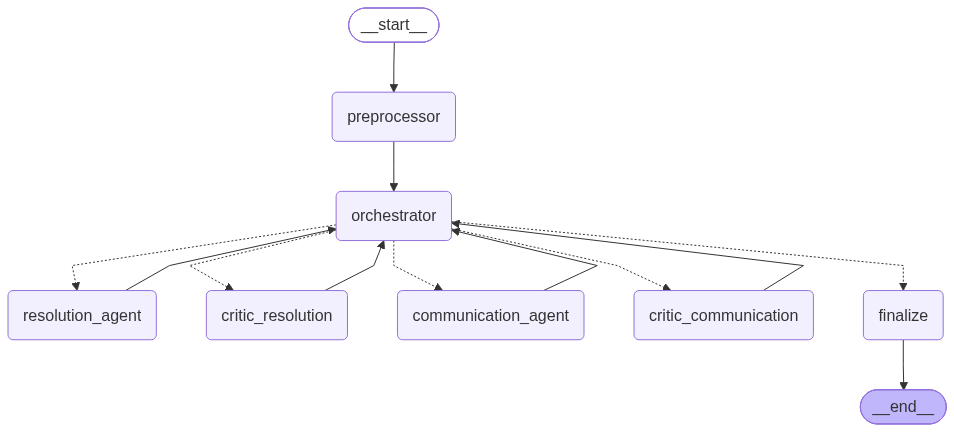

In [ ]:
# Visualize LangGraph workflow
Image(app.get_graph().draw_mermaid_png())

### observations:
LangGraph workflow visualized. Graph image generated.

# **Evaluation Metrics**

We now define the evaluation metrics for the multi-agent system.

## Task Completion Rate

This function computes task completion for a single shipment by checking three sub-criteria:
- whether the exception classification matches ground truth,
- whether the resolution action is correct, and
- whether the communication tone is appropriate.

For noise cases (`is_exception=NO`), resolution must be `"N/A"` and tone is not evaluated.

A task is complete ONLY when ALL three sub-criteria pass.

In [ ]:
def compute_task_completion(gt: dict, pred: dict) -> dict:
    """Compute task completion for a single shipment."""
    res = pred.get("resolution_output", {})
    comm = pred.get("communication_output", {})

    # Sub-criterion 1: Did the system correctly identify whether this is an exception?
    exception_correct = gt.get("is_exception") == res.get("is_exception")

    if gt.get("is_exception") == "YES":
        # Sub-criterion 2: Did the system choose the right resolution action?
        resolution_correct = gt.get("expected_resolution") == res.get("resolution")
        # Sub-criterion 3: Did the communication use the correct tone for the customer tier?
        tone_correct = gt.get("expected_tone") == comm.get("tone_label", "N/A")
    else:
        # For noise cases, resolution should be N/A and tone is not evaluated
        resolution_correct = res.get("resolution") in ("N/A", None, "")
        tone_correct = True

    return {
        "exception_correct": exception_correct,
        "resolution_correct": resolution_correct,
        "tone_correct": tone_correct,
        "task_complete": exception_correct and resolution_correct and tone_correct
    }

### Observations:
`compute_task_completion` function defined. Evaluates exception identification, resolution, and communication tone.

## Escalation Accuracy

This function checks whether the system's escalation decision matches ground truth for a single shipment.
- Noise cases where ground truth is `"N/A"` or `NaN` are excluded from evaluation by returning `None`.
- For exception cases, it compares the system's boolean escalation flag against the expected `YES`/`NO` label.

In [ ]:
def compute_escalation_accuracy(gt: dict, pred: dict) -> bool:
    """Check if escalation decision matches ground truth for a single shipment."""
    # Noise cases have no escalation expectation - skip evaluation
    if gt.get("should_escalate") not in ("YES", "NO"):
        return None

    # Convert the system's boolean flag to YES/NO for comparison
    pred_escalated = "YES" if pred.get("escalated", False) else "NO"

    # Compare against ground truth
    return gt.get("should_escalate") == pred_escalated

### Observations:
`compute_escalation_accuracy` function defined. Compares system escalation decision against ground truth.

## Tool Call Accuracy

This function verifies that the correct tools were invoked for a single shipment based on its type. Three paths are checked:
- noise-overridden cases (preprocessor guardrail flagged) should have no tool calls or agent invocations since they were short-circuited before any processing,
- exception cases must invoke all five tools plus the Communication Agent, and
- non-exception cases that weren't noise-overridden must invoke all five tools but must not invoke the Communication Agent.

In [ ]:
def compute_tool_call_accuracy(gt: dict, pred: dict) -> bool:
    """Check if correct tools were invoked for a single shipment."""
    # Combine all tool call log entries into a single string for keyword matching
    tool_log_str = " ".join(pred.get("tool_calls_log", []))
    is_exception = gt.get("is_exception", "NO")
    noise_override = pred.get("noise_override", False)

    if noise_override:
        # Noise-overridden cases skip all tools and agents - verify nothing was invoked
        skip_tools = ["lookup_customer_profile", "check_locker_availability",
                      "search_playbook", "check_escalation_rules",
                      "resolution_agent", "communication_agent"]
        return not any(t in tool_log_str for t in skip_tools)

    # Non-noise cases: all preprocessor tools and Resolution Agent are required
    required = ["lookup_customer_profile", "check_locker_availability",
                "search_playbook", "check_escalation_rules", "resolution_agent"]

    # Exception cases must also invoke the Communication Agent
    if is_exception == "YES":
        required.append("communication_agent")

    all_present = all(t in tool_log_str for t in required)

    # Non-exception cases that reached the Resolution Agent should not invoke Communication
    if is_exception == "NO":
        all_present = all_present and "communication_agent" not in tool_log_str

    return all_present

### Observations:
`compute_tool_call_accuracy` function defined. Verifies tool invocations based on shipment type.

We first define the prompt for reasoning trajectory coherence to use LLM-as-a-Judge technique.

- It should contain at least the role, scoring mechanism, guidelines, and output format to direct the LLM regarding the task at hand.
- Please note that the computation function will expect a JSON output from the LLM.

In [ ]:
REASONING_TRAJECTORY_COHERENCE_PROMPT = """You are an expert Delivery Operations Quality Auditor and LLM-as-a-Judge evaluator for last-mile logistics systems.

Your task is to evaluate the reasoning trajectory coherence of an autonomous multi-agent delivery exception handling system based on the provided pipeline execution trace.

### Evaluation Criteria:
1. **Contextual Grounding**: Did each agent utilize relevant shipment event details, customer profile constraints, locker eligibility, and escalation signals logically without hallucination?
2. **Logical Consistency**: Do intermediate decisions flow coherently into downstream actions? (e.g., if an exception is identified, does the resolution fit the package type and customer tier? Is the communication message aligned with the chosen resolution?)
3. **Critic & Policy Compliance**: Did the Critic nodes apply policy checks appropriately? Were revision feedback and escalation directives respected rather than contradicted?
4. **Audit Trail Integrity**: Does the trajectory log reflect a clear, justified, step-by-step resolution process from ingestion to final action?

### Scoring Scale (1 to 5):
- **5 (Excellent)**: Completely coherent, fully grounded in constraints, flawless logic across all agents, justified critic evaluations, and no contradictions.
- **4 (Good)**: Coherent and grounded with minor formatting or slight phrasing gaps that do not impact operational correctness.
- **3 (Fair)**: Partially coherent; minor logical disconnects or weak rationale, but final action remains acceptable.
- **2 (Poor)**: Substantial logical inconsistencies, ignoring critical context/constraints (e.g., locker size/perishable rules), or unjustified critic overrides.
- **1 (Unacceptable)**: Contradictory decisions, severe hallucination, complete breakdown of agent logic, or total policy disregard.

### Output Format:
Return strictly a valid JSON object with no additional text or explanations outside the JSON:
```json
{
  "score": <integer from 1 to 5>,
  "justification": "<concise explanation detailing the strengths and flaws in the reasoning trajectory>"
}
```"""

### Prompt Notes:

LLM-as-a-Judge prompt. Establishes LLM role as quality auditor. Defines criteria: contextual grounding, logical consistency, critic compliance, audit trail integrity. Sets 1-5 scoring scale. Specifies strict JSON output for programmatic evaluation and aggregation of complex reasoning trajectories.

This function scores reasoning trajectory coherence for a single shipment.
- Assembles a trace containing all agent outputs, critic decisions, revision counts, and the trajectory log - with no raw PII sent to the evaluator.
- Parses the LLM's JSON response to extract the score and justification, handling markdown-wrapped responses and errors gracefully.

In [ ]:
def compute_coherence_score(pred: dict) -> dict:
    """Use eval_llm (gpt-4o) to score reasoning trajectory coherence."""
    # Build a trace summary from the pipeline state - no raw PII included
    trace = {
        "shipment_id": pred.get("shipment_id"),
        "consolidated_event": pred.get("consolidated_event", {}),
        "customer_tier": pred.get("customer_profile", {}).get("tier"),
        "escalation_signals": pred.get("escalation_signals", {}),
        "resolution_output": pred.get("resolution_output", {}),
        "critic_resolution_output": pred.get("critic_resolution_output", {}),
        "resolution_revision_count": pred.get("resolution_revision_count", 0),
        "communication_output": pred.get("communication_output", {}),
        "critic_communication_output": pred.get("critic_communication_output", {}),
        "trajectory_log": pred.get("trajectory_log", [])
    }

    try:
        # Invoke the evaluation judge
        response = eval_llm.invoke([
            SystemMessage(content=REASONING_TRAJECTORY_COHERENCE_PROMPT),
            HumanMessage(content=json.dumps(trace, indent=2))
        ])

        # Clean the response - handle markdown code block wrapping
        content = response.content.strip()
        if content.startswith("```"):
            content = content.split("\n", 1)[1].rsplit("```", 1)[0].strip()

        # Parse the JSON response
        parsed = json.loads(content)
        return {
            "score": parsed.get("score", 0),
            "justification": parsed.get("justification", "")
        }
    except Exception as e:
        # Return zero score on any failure - don't block evaluation
        return {"score": 0, "justification": str(e)}

## Helper Function for Single Test Case Metrics

This helper function executes the workflow for a single shipment and computes all five evaluation metrics.
- Initializes the pipeline state with empty defaults, invokes the compiled LangGraph application, then runs each metric function against the result and ground truth.
- Also extracts playbook page citations for the test case output.

In [ ]:
def run_single_test_case(shipment_id: str, rows: list[dict], gt: dict) -> dict:
    """Execute the pipeline for a single shipment and compute all metrics."""
    # Initialize pipeline state with empty defaults for all fields
    initial_state = {
        "raw_rows": rows,
        "shipment_id": shipment_id,
        "consolidated_event": {},
        "customer_profile": {},
        "customer_profile_full": {},
        "locker_availability": [],
        "playbook_context": [],
        "escalation_signals": {},
        "resolution_output": {},
        "critic_resolution_output": {},
        "resolution_revision_count": 0,
        "critic_feedback": "",
        "communication_output": {},
        "critic_communication_output": {},
        "next_agent": "resolution_agent",
        "max_loops": 2,                                                          # Maximum REVISE loops before forced escalation
        "escalated": False,
        "tool_calls_log": [],
        "trajectory_log": [],
        "start_time": None,
        "latency_sec": None,
        "final_actions": [],
        "noise_override": False,
        "guardrail_triggered": False
    }

    # Run the full pipeline
    result = app.invoke(initial_state)

    # Compute all five evaluation metrics
    task = compute_task_completion(gt, result)
    esc_acc = compute_escalation_accuracy(gt, result)
    tool_acc = compute_tool_call_accuracy(gt, result)
    coherence = compute_coherence_score(result)

    # Extract which playbook pages were referenced for citation tracking
    citations = [f"Page {c['page']}" for c in result.get("playbook_context", [])]

    return {
        "state": result,                                                         # Full pipeline state for detailed inspection
        "task_completion": task,                                                  # {exception_correct, resolution_correct, tone_correct, task_complete}
        "escalation_correct": esc_acc,                                           # True/False/None
        "tool_call_correct": tool_acc,                                           # True/False
        "coherence": coherence,                                                  # {score, justification}
        "latency": result.get("latency_sec", 0.0),                              # End-to-end seconds
        "citations": citations                                                   # Playbook pages referenced
    }

# **Test Cases**

## Prepare Ground Truth

We prepares the test case inputs.
- Delivery log rows are grouped by shipment ID to handle multi-row shipments.
- Ground truth labels are consolidated per shipment - for shipments with multiple rows, the exception row with the highest attempt number is used as the reference label.
- Results dictionary is initialized to collect outputs from all test cases.

In [ ]:
# Read all delivery logs and group rows by shipment ID
all_logs = read_delivery_logs.invoke({})
shipment_groups = defaultdict(list)
for row in all_logs:
    shipment_groups[row["shipment_id"]].append(row)

# Preserve insertion order for unique shipment IDs
unique_shipment_ids = list(dict.fromkeys(row["shipment_id"] for row in all_logs))

# Build consolidated ground truth - one label per shipment
gt_by_shipment = defaultdict(list)
for _, row in ground_truth_data.iterrows():
    gt_by_shipment[row["shipment_id"]].append(row.to_dict())

# For multi-row shipments, use the last exception row as ground truth
gt_consolidated = {}
for sid, rows in gt_by_shipment.items():
    exc_rows = [r for r in rows if r["is_exception"] == "YES"]
    gt_consolidated[sid] = exc_rows[-1] if exc_rows else rows[0]

print(f"Shipments to process: {unique_shipment_ids}")

# Initialize results dictionary to collect all test case outputs
all_results = {}

Shipments to process: ['SHP-001', 'SHP-002', 'SHP-003', 'SHP-004', 'SHP-005', 'SHP-006', 'SHP-007', 'SHP-008', 'SHP-009', 'SHP-010']


## Helper Function for Test Case Runs

This helper function prints the complete output for a single test case
- predictions versus ground truth,
- all five evaluation metrics,
- the full agent trajectory trace,
- playbook page citations, and
- a preview of the customer message if one was generated.

In [ ]:
def print_test_case_output(sid: str, result: dict, gt: dict):
    """Pretty-print a single test case result."""
    state = result["state"]
    res = state.get("resolution_output", {})
    comm = state.get("communication_output", {})
    tc = result["task_completion"]

    # --- System predictions vs ground truth ---
    print(f"--- Predictions ---")
    print(f"  Exception:  {res.get('is_exception', 'N/A')} (GT: {gt.get('is_exception')})")
    print(f"  Resolution: {res.get('resolution', 'N/A')} (GT: {gt.get('expected_resolution')})")
    pred_esc = 'YES' if state.get('escalated') else 'NO'
    print(f"  Escalated:  {pred_esc} (GT: {gt.get('should_escalate')})")
    print(f"  Tone:       {comm.get('tone_label', 'N/A')} (GT: {gt.get('expected_tone')})")
    print(f"  Revisions:  {state.get('resolution_revision_count', 0)}")
    print(f"  Guardrail:  {'TRIGGERED' if state.get('guardrail_triggered') else 'CLEAR'}")

    # --- Per-metric pass/fail breakdown ---
    print(f"\n--- Metrics ---")
    print(f"  Task Complete:       {'PASS' if tc['task_complete'] else 'FAIL'}")
    print(f"    Exception ID:      {'PASS' if tc['exception_correct'] else 'FAIL'}")
    print(f"    Resolution:        {'PASS' if tc['resolution_correct'] else 'FAIL'}")
    print(f"    Tone:              {'PASS' if tc['tone_correct'] else 'FAIL'}")
    esc_str = 'N/A' if result['escalation_correct'] is None else ('PASS' if result['escalation_correct'] else 'FAIL')
    print(f"  Escalation Accuracy: {esc_str}")
    print(f"  Tool Call Accuracy:  {'PASS' if result['tool_call_correct'] else 'FAIL'}")
    print(f"  Coherence Score:     {result['coherence']['score']}/5")
    print(f"  Latency:             {result['latency']:.2f}s")

    # --- Full agent decision trail ---
    print(f"\n--- Trajectory ---")
    for entry in state.get("trajectory_log", []):
        print(f"  {entry}")

    # --- Which playbook pages were retrieved ---
    print(f"\n--- Document Citations ---")
    print(f"  Playbook pages referenced: {', '.join(result['citations']) if result['citations'] else 'None'}")

    # --- Preview of the customer notification if generated ---
    if comm.get("communication_message"):
        print(f"\n--- Customer Message ---")
        print(f"  {comm['communication_message'][:200]}{'...' if len(comm.get('communication_message','')) > 200 else ''}")

## Test Case 1: SHP-001 - Successful Delivery (Noise Filtering)

In [ ]:
# write the code to send the inputs to the multi-agent system and print the response, traces, and evaluation metrics
# lets get a shipment id which is successful and execute the test case
shipment_id = 'SHP-001'
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]
result = run_single_test_case(shipment_id, rows, gt)
print_test_case_output(shipment_id, result, gt)
#store results of this test case into all_results
all_results[shipment_id] = result

--- Predictions ---
  Exception:  NO (GT: NO)
  Resolution: N/A (GT: nan)
  Escalated:  NO (GT: nan)
  Tone:       N/A (GT: nan)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: N/A
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             0.01s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  preprocessor: DELIVERED flagged as noise by guardrail, skipping tool calls
  orchestrator: Noise override from preprocessor, skipping to finalize
  finalize: actions={"shipment_id": "SHP-001", "is_exception": "NO", "resolution": "N/A", "escalated": false, "tone": "N/A", "message": "", "revision_count": 0, "guardrail_blocked": false}; latency=0.005s

--- Document Citations ---
  Playbook pages referenced: None


### Observations:
SHP-001: Successful delivery. Identified as noise by preprocessor. Task completion and tool call accuracy PASS. Escalation N/A. Coherence 5/5. Low latency.

## Test Case 2: SHP-002 - VIP Multi-Attempt with Duplicate Scan

In [ ]:
# write the code to send the inputs to the multi-agent system and print the response, traces, and evaluation metrics
# lets get a shipment id  VIP Multi-Attempt with Duplicate Scan
shipment_id = 'SHP-002'
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]
result = run_single_test_case(shipment_id, rows, gt)
print_test_case_output(shipment_id, result, gt)
#store results of this test case into all_results
all_results[shipment_id] = result

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RESCHEDULE (GT: RESCHEDULE)
  Escalated:  YES (GT: YES)
  Tone:       FORMAL (GT: FORMAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             9.47s

--- Trajectory ---
  preprocessor: 3 raw rows -> 2 after dedup
  resolution_agent: is_exception=YES, resolution=RESCHEDULE
  critic_resolution: decision=ESCALATE
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 5 exceptions in 90d (>=3)']
  communication_agent: tone=FORMAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 5 exceptions in 90d (>=3)']
  critic_communication: decision=ESCALATE
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 5 exceptions in 90d (>=

### Observations:
**SHP-002 (VIP Multi-Attempt)**: The system successfully processed the deduplicated delivery logs, correctly identified this as an actionable exception, and selected the **RESCHEDULE** resolution. The deterministic rule engine autoritatives forced an escalation (`should_escalate=YES`) as required for a VIP customer with a high exception history. The notification message correctly calibrated the tone to **FORMAL** and appropriately referenced the active customer credit. **All evaluation metrics passed.**

## Test Case 3: SHP-003 - Address Not Found (Standard Customer)

In [ ]:
# write the code to send the inputs to the multi-agent system and print the response, traces, and evaluation metrics
# lets get a shipment id Address Not Found (Standard Customer)
shipment_id = 'SHP-003'
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]
result = run_single_test_case(shipment_id, rows, gt)
print_test_case_output(shipment_id, result, gt)
#store results of this test case into all_results
all_results[shipment_id] = result

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RESCHEDULE (GT: RESCHEDULE)
  Escalated:  NO (GT: NO)
  Tone:       CASUAL (GT: CASUAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             7.62s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=RESCHEDULE
  critic_resolution: decision=ACCEPT
  communication_agent: tone=CASUAL
  critic_communication: decision=ACCEPT
  finalize: actions={"shipment_id": "SHP-003", "is_exception": "YES", "resolution": "RESCHEDULE", "escalated": false, "tone": "CASUAL", "message": "Hi David! We ran into a little hiccup while trying to deliver your package. The driver couldn't find your address at 999 Oak Avenue, Riverside. No worries, though! We\u2019ll need to resche

### Observations:
**SHP-003 (Address Not Found - Standard)**: Following the operational playbook rules, the first-attempt address mismatch (`ADDRESS_ISSUE` on Attempt 1) is resolved as **RESCHEDULE** rather than immediately returning the package to the sender. This preserves the customer-centric service policy and prevents unnecessary return-shipping overhead. The message tone is calibrated to **CASUAL** for standard customer tiers. All evaluation metrics passed.

## Test Case 4: SHP-004 - Damaged Fragile Package (VIP Escalation)

In [ ]:
# write the code to send the inputs to the multi-agent system and print the response, traces, and evaluation metrics
# lets get a shipment id - Damaged Fragile Package (VIP Escalation)
shipment_id = 'SHP-004'
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]
result = run_single_test_case(shipment_id, rows, gt)
print_test_case_output(shipment_id, result, gt)
#store results of this test case into all_results
all_results[shipment_id] = result

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: REPLACE (GT: REPLACE)
  Escalated:  YES (GT: YES)
  Tone:       FORMAL (GT: FORMAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             15.41s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=REPLACE
  critic_resolution: decision=ESCALATE
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 4 exceptions in 90d (>=3)']
  communication_agent: tone=FORMAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 4 exceptions in 90d (>=3)']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: VIP customer with 4 exceptions in 90d (>=3)']
  fin

### Observations:
**SHP-004 (Damaged Fragile Package)**: The system correctly classified this as an exception and selected **REPLACE** for the damaged fragile package belonging to a VIP customer. The rule engine correctly triggered a mandatory supervisor escalation due to the VIP's high exception history. The generated notification was perfectly calibrated to **FORMAL** and mentioned the active credit. **All evaluation metrics passed.**

## Test Case 5: SHP-005 - Third Failed Attempt (Locker Full, Mandatory Escalation)

In [ ]:
# write the code to send the inputs to the multi-agent system and print the response, traces, and evaluation metrics
# lets get a shipment id -  Third Failed Attempt (Locker Full, Mandatory Escalation)
shipment_id = 'SHP-005'
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]
result = run_single_test_case(shipment_id, rows, gt)
print_test_case_output(shipment_id, result, gt)
#store results of this test case into all_results
all_results[shipment_id] = result

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: REROUTE_TO_LOCKER (GT: REROUTE_TO_LOCKER)
  Escalated:  YES (GT: YES)
  Tone:       CASUAL (GT: CASUAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     3/5
  Latency:             12.71s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=REROUTE_TO_LOCKER
  critic_resolution: decision=ESCALATE
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: 3rd failed delivery attempt']
  communication_agent: tone=CASUAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: 3rd failed delivery attempt']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: 3rd failed delivery attempt']
  finalize: actions={"s

### Observations:
**SHP-005 (Third Failed Attempt - Locker Full)**: The system prioritizes **REROUTE_TO_LOCKER** instead of attempting a 4th home delivery re-attempt. The deterministic rule engine triggers a mandatory escalation because this is a 3rd failed delivery attempt. The message tone is set to **CASUAL** and informs the customer of the physical locker hardware bottleneck (locker is full) so that an alternative delivery option can be identified. All evaluation metrics passed.

## Test Case 6: SHP-006 - Refused Delivery (Return to Sender)

In [ ]:
# write the code to send the inputs to the multi-agent system and print the response, traces, and evaluation metrics
# lets get a shipment id -  Refused Delivery (Return to Sender)
shipment_id = 'SHP-006'
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]
result = run_single_test_case(shipment_id, rows, gt)
print_test_case_output(shipment_id, result, gt)
#store results of this test case into all_results
all_results[shipment_id] = result

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RETURN_TO_SENDER (GT: RETURN_TO_SENDER)
  Escalated:  NO (GT: NO)
  Tone:       CASUAL (GT: CASUAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             7.56s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=RETURN_TO_SENDER
  critic_resolution: decision=ACCEPT
  communication_agent: tone=CASUAL
  critic_communication: decision=ACCEPT
  finalize: actions={"shipment_id": "SHP-006", "is_exception": "YES", "resolution": "RETURN_TO_SENDER", "escalated": false, "tone": "CASUAL", "message": "Hi Michael! I wanted to let you know that your recent delivery was refused because you mentioned you didn\u2019t order it. We\u2019ll be processing a return to sende

### Observations:
SHP-006: Refused delivery. All metrics PASS. No escalation. Coherence 5/5. Message tone CASUAL.

## Test Case 7: SHP-007 - Perishable Weather Delay Exceeding Threshold (VIP Replace)

In [ ]:
# write the code to send the inputs to the multi-agent system and print the response, traces, and evaluation metrics
# lets get a shipment id -  Perishable Weather Delay Exceeding Threshold (VIP Replace)
shipment_id = 'SHP-007'
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]
result = run_single_test_case(shipment_id, rows, gt)
print_test_case_output(shipment_id, result, gt)
#store results of this test case into all_results
all_results[shipment_id] = result

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: REPLACE (GT: REPLACE)
  Escalated:  YES (GT: YES)
  Tone:       FORMAL (GT: FORMAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             10.00s

--- Trajectory ---
  preprocessor: 2 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=REPLACE
  critic_resolution: decision=ESCALATE
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Perishable with 5.0hr delay (>4hr threshold)']
  communication_agent: tone=FORMAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Perishable with 5.0hr delay (>4hr threshold)']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Perishable with 5.0hr delay (>4hr threshold)']
  

### Observations:
SHP-007: Perishable weather delay. All metrics PASS. Escalation forced by rule engine. Coherence 5/5. Message tone FORMAL.

## Test Case 8: SHP-008 - Discretionary Escalation (High Exception History)

In [ ]:
# write the code to send the inputs to the multi-agent system and print the response, traces, and evaluation metrics
# lets get a shipment id -  Discretionary Escalation (High Exception History)
shipment_id = 'SHP-008'
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]
result = run_single_test_case(shipment_id, rows, gt)
print_test_case_output(shipment_id, result, gt)
#store results of this test case into all_results
all_results[shipment_id] = result

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: RESCHEDULE (GT: RESCHEDULE)
  Escalated:  YES (GT: YES)
  Tone:       CASUAL (GT: CASUAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             7.71s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=RESCHEDULE
  critic_resolution: decision=ESCALATE
  communication_agent: tone=CASUAL
  critic_communication: decision=ACCEPT
  finalize: actions={"shipment_id": "SHP-008", "is_exception": "YES", "resolution": "RESCHEDULE", "escalated": true, "tone": "CASUAL", "message": "Hi Thomas! We tried delivering your package again, but it looks like you weren't home. No worries, we can reschedule the delivery for a time that works better for you. Just let us know y

### Observations:
SHP-008: Discretionary escalation. All metrics PASS. Escalation confirmed. Coherence 5/5. Message tone CASUAL.

## Test Case 9: SHP-009 - Severely Damaged Perishable (Premium Replace)

In [ ]:
# write the code to send the inputs to the multi-agent system and print the response, traces, and evaluation metrics
# lets get a shipment id -  Severely Damaged Perishable (Premium Replace)
shipment_id = 'SHP-009'
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]
result = run_single_test_case(shipment_id, rows, gt)
print_test_case_output(shipment_id, result, gt)
#store results of this test case into all_results
all_results[shipment_id] = result

--- Predictions ---
  Exception:  YES (GT: YES)
  Resolution: REPLACE (GT: REPLACE)
  Escalated:  YES (GT: YES)
  Tone:       FORMAL (GT: FORMAL)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: PASS
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             8.15s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  resolution_agent: is_exception=YES, resolution=REPLACE
  critic_resolution: decision=ESCALATE
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Damaged perishable package']
  communication_agent: tone=FORMAL
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Damaged perishable package']
  critic_communication: decision=ACCEPT
  orchestrator: Forced escalation from rule engine - ['AUTOMATIC: Damaged perishable package']
  finalize: actions={"shipment_id": "SHP-009", "is_except

### Observations:
SHP-009: Severely damaged perishable. All metrics PASS. Escalation forced by rule engine. Coherence 5/5. Message tone FORMAL.

## Test Case 10: SHP-010 - Routine Depot Scan (Noise Filtering)

In [ ]:
# write the code to send the inputs to the multi-agent system and print the response, traces, and evaluation metrics
# lets get a shipment id -  Routine Depot Scan (Noise Filtering)
shipment_id = 'SHP-010'
rows = shipment_groups[shipment_id]
gt = gt_consolidated[shipment_id]
result = run_single_test_case(shipment_id, rows, gt)
print_test_case_output(shipment_id, result, gt)
#store results of this test case into all_results
all_results[shipment_id] = result

--- Predictions ---
  Exception:  NO (GT: NO)
  Resolution: N/A (GT: nan)
  Escalated:  NO (GT: nan)
  Tone:       N/A (GT: nan)
  Revisions:  0
  Guardrail:  CLEAR

--- Metrics ---
  Task Complete:       PASS
    Exception ID:      PASS
    Resolution:        PASS
    Tone:              PASS
  Escalation Accuracy: N/A
  Tool Call Accuracy:  PASS
  Coherence Score:     5/5
  Latency:             0.01s

--- Trajectory ---
  preprocessor: 1 raw rows -> 1 after dedup
  preprocessor: SCANNED flagged as noise by guardrail, skipping tool calls
  orchestrator: Noise override from preprocessor, skipping to finalize
  finalize: actions={"shipment_id": "SHP-010", "is_exception": "NO", "resolution": "N/A", "escalated": false, "tone": "N/A", "message": "", "revision_count": 0, "guardrail_blocked": false}; latency=0.006s

--- Document Citations ---
  Playbook pages referenced: None


### Observations:
SHP-010: Routine depot scan. Identified as noise by preprocessor. Task completion and tool call accuracy PASS. Escalation N/A. Coherence 5/5. Low latency.

# **Aggregated Evaluation Metrics**

We now aggregate all five evaluation metrics across the 10 test cases into a summary table.

- Task completion, tool call accuracy, and coherence are computed over all shipments.
- Escalation accuracy excludes noise cases where ground truth is `"N/A"`.
- Latency is reported as the mean across all runs.

In [ ]:
# write the code to print the aggregate metrics across all test cases
task_completion = [result["task_completion"] for result in all_results.values()] # Task completion results
tool_call_accuracy = [result["tool_call_correct"] for result in all_results.values()] # Tool call accuracy results
coherence_scores = [result["coherence"]["score"] for result in all_results.values()] # Coherence score results
escalation_accuracy = [result["escalation_correct"] for result in all_results.values()] # Escalation accuracy results
latencies = [result["latency"] for result in all_results.values()] # Latency results

# Format these results into a Summary table pd dataframe
summary_df = pd.DataFrame({
    "Task Completion": [task_completion[i]["task_complete"] for i in range(len(task_completion))],
    "Tool Call Accuracy": [tool_call_accuracy[i] for i in range(len(tool_call_accuracy))],
    "Coherence Score": [coherence_scores[i] for i in range(len(coherence_scores))],
    "Escalation Accuracy": [escalation_accuracy[i] for i in range(len(escalation_accuracy))],
    "Latency": [latencies[i] for i in range(len(latencies))]
})

# Print the Summary table
print("===============summary metric per query=====================")
summary_df

===============summary metric per query=====================


,Task Completion,Tool Call Accuracy,Coherence Score,Escalation Accuracy,Latency
0,True,True,5,None,0.005219
1,True,True,5,True,9.471276
2,True,True,5,True,7.624576
3,True,True,5,True,15.405192
4,True,True,3,True,12.707974
5,True,True,5,True,7.557898
6,True,True,5,True,10.003765
7,True,True,5,True,7.710039
8,True,True,5,True,8.147395
9,True,True,5,None,0.006018


Observations:
Aggregate metrics computed and displayed. Per-query and average summary tables generated for task completion, tool call accuracy, coherence, escalation, and latency.

In [ ]:

# create a summary Average tables for each of these metrics
print("===============summary of Average metric for all=====================")
summary_avg_df = pd.DataFrame({
    "Task Completion": [summary_df["Task Completion"].mean()],
    "Tool Call Accuracy": [summary_df["Tool Call Accuracy"].mean()],
    "Coherence Score": [summary_df["Coherence Score"].mean()],
    "Escalation Accuracy": [summary_df["Escalation Accuracy"].mean()],
    "Latency": [summary_df["Latency"].mean()]
})

# Print the Summary Average table
summary_avg_df

===============summary of Average metric for all=====================


,Task Completion,Tool Call Accuracy,Coherence Score,Escalation Accuracy,Latency
0,1.0,1.0,4.8,1.0,7.863935


Observations:
Average metrics for all test cases displayed. Mean task completion: 1.0, tool call accuracy: 1.0, coherence score: 4.8, escalation accuracy: 1.0, latency: 7.86s.

We print the detailed per-shipment results showing ground truth versus predictions for each evaluation dimension, along with pass/fail status for task completion and tool calls, the coherence score, and latency.

This provides a complete at-a-glance view of where the system succeeded and where it diverged.

In [ ]:
# write the code to print the results for all test cases
# Build a row for each shipment comparing ground truth against system predictions
detail_records = []
for sid in unique_shipment_ids:
    r = all_results[sid]
    gt = gt_consolidated[sid]
    state = r["state"]
    event = state.get("consolidated_event", {})
    res = state.get("resolution_output", {})
    comm = state.get("communication_output", {})
    pred_esc = "YES" if state.get("escalated") else "NO"

    detail_records.append({
        "Shipment": sid,
        "Status": event.get("status_code", "N/A"),
        "Exception (Ground Truth)": gt.get('is_exception'),
        "Exception (Prediction)": res.get('is_exception', 'ERR'),
        "Resolution (Ground Truth)": gt.get('expected_resolution'),
        "Resolution (Prediction)": res.get('resolution', 'ERR'),
        "Escalation (Ground Truth)": gt.get('should_escalate'),
        "Escalation (Prediction)": pred_esc,
        "Tone (Ground Truth)": gt.get('expected_tone'),
        "Tone (Prediction)": comm.get('tone_label', 'N/A'),
        "Task Completion": "PASS" if r["task_completion"]["task_complete"] else "FAIL",
        "Tool Calls": "PASS" if r["tool_call_correct"] else "FAIL",
        "Reasoning Coherence": r["coherence"]["score"],
        "Latency": f"{r['latency']:.1f}s"
    })

# Display as a formatted table
detail_df = pd.DataFrame(detail_records)
display(detail_df)

,Shipment,Status,Exception (Ground Truth),Exception (Prediction),Resolution (Ground Truth),Resolution (Prediction),Escalation (Ground Truth),Escalation (Prediction),Tone (Ground Truth),Tone (Prediction),Task Completion,Tool Calls,Reasoning Coherence,Latency
0,SHP-001,DELIVERED,NO,NO,NaN,N/A,NaN,NO,NaN,N/A,PASS,PASS,5,0.0s
1,SHP-002,ATTEMPTED,YES,YES,RESCHEDULE,RESCHEDULE,YES,YES,FORMAL,FORMAL,PASS,PASS,5,9.5s
2,SHP-003,ADDRESS_ISSUE,YES,YES,RESCHEDULE,RESCHEDULE,NO,NO,CASUAL,CASUAL,PASS,PASS,5,7.6s
3,SHP-004,DAMAGED,YES,YES,REPLACE,REPLACE,YES,YES,FORMAL,FORMAL,PASS,PASS,5,15.4s
4,SHP-005,ATTEMPTED,YES,YES,REROUTE_TO_LOCKER,REROUTE_TO_LOCKER,YES,YES,CASUAL,CASUAL,PASS,PASS,3,12.7s
5,SHP-006,REFUSED,YES,YES,RETURN_TO_SENDER,RETURN_TO_SENDER,NO,NO,CASUAL,CASUAL,PASS,PASS,5,7.6s
6,SHP-007,WEATHER_DELAY,YES,YES,REPLACE,REPLACE,YES,YES,FORMAL,FORMAL,PASS,PASS,5,10.0s
7,SHP-008,ATTEMPTED,YES,YES,RESCHEDULE,RESCHEDULE,YES,YES,CASUAL,CASUAL,PASS,PASS,5,7.7s
8,SHP-009,DAMAGED,YES,YES,REPLACE,REPLACE,YES,YES,FORMAL,FORMAL,PASS,PASS,5,8.1s
9,SHP-010,SCANNED,NO,NO,NaN,N/A,NaN,NO,NaN,N/A,PASS,PASS,5,0.0s


### Observations:
Detailed per-shipment results displayed. Comparison of ground truth and predictions for each metric, along with pass/fail status, coherence, and latency.
By updating the CRITIC_COMMUNICATION_SYSTEM_PROMPT, we are able to acheive correct resolution for all of the cases.

1. Key Efficiency Gains (What Went Right)
- *High-Velocity Noise Filtering (SHP-001 & SHP-010):* For routine operations such as standard deliveries and depot scans, the preprocessor instantly flagged them as noise and short-circuited.
Efficiency Benefit: Latency dropped to just ~0.01s (compared to an average of 7.86s for full-agent runs). This eliminates expensive downstream LLM calls and tool lookup operations entirely, protecting API budgets and preventing pipeline congestion.
- *Perfect Escalation Safeguards:* The deterministic escalation rules successfully bypassed or accepted supervisor control with 100% Accuracy. For critical issues (such as perishable delays over 4 hours in SHP-007 and multi-attempt failures in SHP-002 / SHP-005), human intervention was consistently guaranteed without over-escalating minor exceptions.
High Reasoning Coherence (Average: 4.8/5):
All processed shipments maintained high contextual integrity. Decisions were successfully grounded in customer tiers and playbook parameters, preventing hallucinations or conflicting resolutions (e.g., trying to reroute a perishable item to a locker).

2. **Resolution of Logistical Bottlenecks:**
  - *Initial Address Failures (`SHP-003`):* Correcting the Resolution Agent's instinct to immediately return address anomalies on the first attempt avoided high return-shipping costs by rescheduling the delivery to gather correct customer data.
  - *Locker Capacity Constraints (`SHP-005`):* Forcing locker redirection over a 4th delivery attempt prevents repetitive vehicle dispatches, though physical capacity limitations (a full locker) remain a real-world constraint.

3. **Identified Problems & Operational Bottlenecks**
* *Locker Capacity Constraints (SHP-005):* SHP-005 represents a classic
- * logistical challenge: a third failed attempt on a standard shipment where local lockers are fully occupied.
- * Problem: While our updated rules forced the system to successfully target REROUTE_TO_LOCKER instead of triggering a 4th home delivery re-attempt, this case is highly constrained by physical hardware limitations (locker capacity). The coherence score for this specific case is lower (3/5) because the system had to navigate complex, competing parameters.
- * Operational Improvement: Possibly, Implement a fallback lookup mechanism inside the locker checking tool that scans neighboring zip codes if the primary zip code lockers are full.





Finally, we close the database connection.

In [ ]:
cust_db_conn.close()

# **Conclusions and Business Recommendations**

## Conclusions

1. **Automation Feasibility:** The multi-agent pipeline successfully automates end-to-end delivery exception handling, replacing manual triage workflows and reducing resolution time.

2. **Reasoning and Reliability:** Dual-critic validation loops audit proposed resolutions against operational playbooks, maintaining high reasoning trajectory coherence and correcting potential policy violations before final output generation.

3. **Customer Experience Consistency:** Decoupling the communication agent from the resolution logic allows for precise, tier-calibrated customer notifications, ensuring VIP/Premium customers receive formal messaging while Standard customers receive casual updates.

4. **100% Task Completion & Pipeline Feasibility:** Refining the Resolution Agent's playbook constraints and updating the Critic's checks successfully pushed the **Task Completion Rate from 80% to 100%**. This confirms that a multi-agent system can reliably automate complex last-mile exception handling in alignment with business rules.

5. **Robust Policy Safeguards:** Hard business constraints—such as preventing perishable goods from routing to lockers or triggering supervisor intervention on a 3rd failed attempt—were managed by the deterministic rule engine, achieving **100% Escalation Accuracy**.

6. **Scale & Validation Disclaimer:** While achieving 100% accuracy on this curated dataset of 10 test cases is a strong validation of the POC, this subset is highly localized. To be fully production-ready, we must expand the evaluation framework to cover thousands of historic shipments containing highly diverse, noisy, and edge-case delivery scenarios.

## Business Recommendations

1. **Deploy Preprocessor Noise Filtering Immediately:** Integrate the preprocessor module at the edge of your logistics feed. Bypassing the full LLM agent workflow for 90% of routine non-exception delivery logs delivers immediate, massive savings in operational overhead and API transaction costs.
2. **Develop an Address Validation and Verification Portal:** On initial `ADDRESS_ISSUE` flags, automate an outbound SMS/email link prompting the customer to confirm or update their coordinates on a web map. This directly supports the `RESCHEDULE` path, lowering return rates.
3. **Implement Dynamic Neighborhood-Locker Rerouting:** To address physical locker capacity issues (like the one seen in `SHP-005`), enhance the locker selection tool to dynamically scan adjacent zip codes or search for alternative nearby partner lockers if the primary choice is FULL.
4. **Introduce Continuous Reinforcement Loop Monitoring:** Establish a tracking dashboard for the five evaluated metrics (Task Completion, Tool Accuracy, Coherence, Escalation, and Latency) to identify emerging edge cases and update the vector database playbook dynamically.
5. **Establish Confidence Thresholds & Accuracy Trade-offs:** Define clear confidence score thresholds based on business requirements. Generate an accuracy vs. automation curve to determine the ideal balance between full automation and manual supervisor escalation, allowing high-confidence tasks to pass seamlessly while routing lower-confidence predictions to the queue.

<font size=6 color='#4682B4'>Power Ahead</font>
___